In [2]:
from scipy.special import iv, kv, ive, kve, gammaln, gamma, legendre
import numpy as np
import matplotlib.pyplot as plt

In [3]:
rho_0 = 4
epsilon = 0.05 # Strength of diffusive degradation
arg_0 = 2 * epsilon * np.sqrt(rho_0)
arg_e = 2 * epsilon
alpha = 1 # Strength of secretion
beta = 1 # Strength of degradation at surface
B0 = 1 # Number of ligand receptors at cell surface
K = 1 # Capacity of cell receptors (saturation level)
pole_tolerance = 1
lim_tol = 1e-05
zero_tol = 1e-300 # For comparing numbers with 0, because these Bessels get ridiculously tiny with small epsilon
# How did Claude know to use 300? Answer: It was essentially arbitrary

def set_epsilon(val):
  global epsilon, arg_0, arg_e
  epsilon = val
  arg_0 = 2 * epsilon * np.sqrt(rho_0)
  arg_e = 2 * epsilon

def set_rho_0(val):
  global rho_0, arg_0
  rho_0 = val
  arg_0 = 2 * epsilon * np.sqrt(rho_0)

def set_beta(val):
  global beta
  beta = val

def set_B0(val):
  global B0
  B0 = val

def set_K(val):
  global K
  K = val

def set_lim_tol(val):
  global lim_tol
  lim_tol = val

In [ ]:
# Update 5/14/26: Tried these small-arg expansions when epsilon gets small, they don't seem to work effectively;
# probably because they keep canceling each other out in the denominator.

# Edit: Nevermind, when sticking with the regular iv and kv fncs for small args, zero terms are still appearing left and right
# in the denominator of X_l, but none of the Chi values are negative anymore. Not sure why this is happening
# but I think I'll stick with the regular fncs from now on.

# So ok. I'm sticking with the regular fncs. Why are all these 0s still appearing in the denominator of X_l?
# Question 1: Does it matter? Even for normal-sized epsilon, these zeros are still appearing, and the graph
# looked fine. Examining the graph more closely - I'll test for theta behind the cell next and see if the Chis become negative.
# Also, for what it's worth, the iv / kv ratio never seems to be close to zero, which means the denominator
# as a whole is evaluating to close to zero, which is unfortunate cause it makes it a lot harder to debug :(

# Alright, Chi(3, 135) is sus af with the oscillation btwn iterations but actually all these Chis are evaluating
# to positive values which is really good! What to try next?

# Next, ignoring the zero in denom problem for a second, I want to confirm that a higher epsilon leads to
# a lower peak Chi value (or doesn't affect the peak, rather than increase it)
# This is confirmed!

# Ok, so the zero in denominator in X_l is still weird, and I'll definitely come back to it should the need
# arise, but for now by setting the iterations to 50, as demonstrated by my debug plots, the heatmaps converge
# without a problem! Well, sort of; the far field solution is everywhere 0 ( ಠ ͜ʖಠ)

# Oh yeah, also, epsilon still cannot be exactly 0 or else X_l just goes straight to NaN. How to fix...

# Update: The log approximation for the ratio was also breaking the far field solutions. Gemini is apparently pretty useless when it comes to this stuff.

# Now that I've returned everything back to just standard functions, and simply reduced the iterations, the heatmaps are more or less working.
# Here are some observations:
# - The effects of beta almost completely disappear when epsilon is 1, although they are still visible if scrutinizing closely.
# - For eventual publication, might have to figure out how to get rid of that ring artifact at the boundary between the near and far field solutions? Maybe
#   use the averages idea I was talking about? For now though, not a problem.
# - Increasing epsilon leads to a sharper decay in concentration close to the source, and additionally reduces the amplitude of concentration at all points.
# - This one might be an issue: Increasing epsilon leads to concentration values going below 0, which shouldn't really be legal.

# LEAVE-OFF POINT 5/14/26. TODO: Check debug Chi convergence graphs for epsilon = 1 to see if there are any negative values, or if those negatives are just a
# result of the artifacts. If the negative values do exist, this either means epsilon cannot go above a certain max range or the code is broken.
# Think about which one is more likely later.

# 5/15 Start

# Ok, update: The reason why there is a ring artifact in the heatmap at rho = rho_0 is because the series does not converge there, but oscillates
# back and forth probably at a frequency determined by the angle. So, after a certain number of iterations, when it is stopped, it will be
# at a random point in its oscillation - except those artifacts aren't random, are they. So probably a predictable point in its oscillation
# which leads to the artifact. Again, probably don't need to worry about this now but just an observation.

# Also, this is now confirmed why the epsilon < 0 issue is happening: sometimes, when the oscillation is stopped, its value will happen to
# be below 0 at that point. Now that I've confirmed this, I think it's still best to circle back to this issue as it does not impact the anisostropy,
# which is the focus for the next tasks.

In [4]:
def log_iv_over_kv(nu, x):
    """log( iv(nu,x) / kv(nu,x) ) computed stably for any x >= 0."""
    if np.isclose(epsilon, 0., atol=zero_tol):
        # small-argument asymptotics in log-space
        # log iv(nu,x) ~ nu*log(x/2) - gammaln(nu+1)
        # log kv(nu,x) ~ gammaln(nu) - nu*log(x/2) - log(2)   (nu > 0)
      log_iv = nu * np.log(x / 2) - gammaln(nu + 1)
      log_kv = gammaln(nu) - nu * np.log(x / 2) - np.log(2)
      return log_iv - log_kv
    # general: use scaled functions, ratio of ive/kve times exp(-2x)
    # ive = iv*exp(-x), kve = kv*exp(x)  =>  iv/kv = (ive/kve)*exp(-2x)
    log_ratio = np.log(ive(nu, x)) - np.log(kve(nu, x)) + 2 * x
    return log_ratio

def iv_over_kv(nu, x):
    return np.exp(log_iv_over_kv(nu, x))

def iv_kv_sum(nu, x):
    ive_sum = ive(nu - 1, x) + ive(nu + 1, x)
    kve_sum = kve(nu - 1, x) + kve(nu + 1, x)
    return ive_sum, kve_sum

# ── X_l ──────────────────────────────────────────────────────────────────────

def X_l(l):
    if np.isclose(epsilon, 0., atol=lim_tol):
        return X_l_limit(l)

    order = 2 * l + 1
    arg   = arg_0

    log_r    = log_iv_over_kv(order, arg)
    ratio    = np.exp(log_r) # keep for diagnostics

    ive_sum, kve_sum = iv_kv_sum(order, arg)
    inner = np.exp(log_r) * kve_sum + np.exp(2 * arg) * ive_sum

    # if np.isclose(inner, 0.0, atol=zero_tol):
    #     if np.isclose(ratio, 0, atol=zero_tol):
    #         print(f"Zero denominator and zero iv/kv in X_l at l={l}")
    #     else:
    #         print(f"Zero denominator in X_l at l={l}")
    # elif np.isclose(ratio, 0, atol=zero_tol):
    #     print(f"Zero iv/kv in X_l at l={l}")

    # X_l = 2*order*alpha / (sqrt(epsilon)*rho_0) / denom
    #      = 2*order*alpha / (sqrt(epsilon)*rho_0) * exp(arg) / inner
    prefactor = 2 * order * alpha / (epsilon * rho_0)
    return prefactor * np.exp(arg) / inner


# ── Y_l ──────────────────────────────────────────────────────────────────────

def Y_l(l):
    if np.isclose(epsilon, 0., atol=lim_tol):
        return Y_l_limit(l)

    order = 2 * l + 1
    arg   = arg_e

    ive_sum_e, kve_sum_e = iv_kv_sum(order, arg)
    two_beta_1 = 2 * beta + 1
    # sq_eps     = np.sqrt(epsilon)

    numer_scaled = two_beta_1 * ive(order, arg) - epsilon * ive_sum_e
    denom_scaled = two_beta_1 * kve(order, arg) + epsilon * kve_sum_e

    if np.isclose(denom_scaled, 0.0, atol=zero_tol):
        raise Exception("Zero denominator in Y_l (scaled)")

    ratio_nd = numer_scaled / denom_scaled

    return -X_l(l) * ratio_nd * np.exp(2 * arg)


# ── Z_l ──────────────────────────────────────────────────────────────────────

def Z_l(l):
    if np.isclose(epsilon, 0., atol=lim_tol):
        return Z_l_limit(l)

    order = 2 * l + 1
    log_r0 = log_iv_over_kv(order, arg_0)
    return X_l(l) * np.exp(log_r0) + Y_l(l)


# ── radial functions ──────────────────────────────────────────────────────────

def R_l_lt(rho, l):
    if np.isclose(epsilon, 0., atol=lim_tol):
        return R_l_lt_limit(rho, l)
    order = 2 * l + 1
    arg   = 2 * epsilon * np.sqrt(rho)
    return (X_l(l) * ive(order, arg) * np.exp(arg)
            + Y_l(l) * kve(order, arg) * np.exp(-arg)) / np.sqrt(rho)


def R_l_gt(rho, l):
    if np.isclose(epsilon, 0., atol=lim_tol):
        return R_l_gt_limit(rho, l)
    order = 2 * l + 1
    arg   = 2 * epsilon * np.sqrt(rho)
    return Z_l(l) * kve(order, arg) * np.exp(-arg) / np.sqrt(rho)


# ── limiting cases ──────────────────────────────────────────────────────────

def X_l_limit (l):
  return alpha / rho_0 ** (l + 1)

def Y_l_limit (l):
  return X_l_limit(l) * (l - beta) / (l + beta + 1)

def Z_l_limit (l):
  return X_l_limit(l) * rho_0 ** (2*l + 1) + Y_l_limit(l)

def R_l_lt_limit (rho, l):
  return X_l_limit(l) * rho ** l + Y_l_limit(l) / rho ** (l + 1)

def R_l_gt_limit (rho, l):
  return Z_l_limit(l) / rho ** (l + 1)

In [ ]:
# Conclusions from this cell:
# e=0.0001 cannot go above 25 iters
# e=0.001 cannot go above 30 iters
# e=0.01 cannot go above 35 iters
# e=0.1 cannot go above 45 iters
# e=1 and above is chill
# There is no significant difference between calculating the values the way I was and using
# the approximations, ive, kve, etc. Probably it is just due to the values being
# so incredibly small.
# Tbh we could totally just make the default number of iterations 25;

# Update 6/11/26: WOAAHHHH By taking epsilon -> epsilon^2 I have basically eliminated the convergence issue!
# If my math is actually correct, this is great!
# ...nevermind. I was using the limiting case and thinking it was the actual case.
# Ok, what's actually changed is since epsilon -> epsilon^2, epsilon can only get half as many orders of magnitude as small before NaNs start creeping into the calculations.
# But on the flip side, since since epsilon -> epsilon^2, the error between the limiting case and the actual case will be tolerable for twice as many orders of magnitude.
# So by changing the limit tolerance, the problem is fixed, and we keep n=25 iterations as a good default.

# ── Debug cell ────────────────────────────────────────────────────────────────
test_ls = [0, 1, 2, 5, 10, 20, 25, 30, 35, 40, 45, 50, 75, 100]
set_epsilon(0.01)

print(f"Global params: epsilon={epsilon}, rho_0={rho_0}, arg_0={arg_0}, arg_e={arg_e}\n")

for l in test_ls:
    order = 2*l + 1
    print(f"── l={l}, order={order} ──")

    # ── iv/kv ratio ──
    log_r = log_iv_over_kv(order, arg_0)
    ratio_stable   = np.exp(log_r)
    ratio_naive    = iv(order, arg_0) / kv(order, arg_0)
    print(f"  iv/kv (stable) = {ratio_stable:.6g},  iv/kv (naive) = {ratio_naive:.6g}")

    # ── X_l inner / denom ──
    ive_sum, kve_sum = iv_kv_sum(order, arg_0)
    inner = np.exp(log_r) * kve_sum + np.exp(2 * arg_0) * ive_sum
    denom = np.exp(arg_0) / inner

    iv_sum_naive  = iv(order-1, arg_0) + iv(order+1, arg_0)
    kv_sum_naive  = kv(order-1, arg_0) + kv(order+1, arg_0)
    denom_naive   = ratio_naive * kv_sum_naive + iv_sum_naive
    print(f"  inner={inner:.6g}, denom (stable)={denom:.6g},  denom (naive)={denom_naive:.6g}")

    # ── X_l ──
    Xl       = X_l(l)
    Xl_limit = X_l_limit(l)
    prefactor = 2 * order * alpha / (epsilon * rho_0)
    Xl_naive  = prefactor / denom_naive
    print(f"  X_l (stable)={Xl:.6g},  X_l (naive)={Xl_naive:.6g},  X_l_limit={Xl_limit:.6g}")

    # ── Y_l numerator / denominator ──
    ive_sum_e, kve_sum_e = iv_kv_sum(order, arg_e)
    two_beta_1 = 2*beta + 1
    sq_eps     = epsilon

    numer_scaled = two_beta_1 * ive(order, arg_e) - sq_eps * ive_sum_e
    denom_scaled = two_beta_1 * kve(order, arg_e) + sq_eps * kve_sum_e
    ratio_nd     = numer_scaled / denom_scaled

    numer_naive = two_beta_1 * iv(order, arg_e) - sq_eps * (iv(order-1, arg_e) + iv(order+1, arg_e))
    denom_naive_y = two_beta_1 * kv(order, arg_e) + sq_eps * (kv(order-1, arg_e) + kv(order+1, arg_e))
    ratio_nd_naive = numer_naive / denom_naive_y
    print(f"  numer_scaled={numer_scaled:.6g}, denom_scaled={denom_scaled:.6g}, ratio_nd={ratio_nd:.6g}")
    print(f"  numer (naive)={numer_naive:.6g}, denom (naive)={denom_naive_y:.6g}, ratio_nd (naive)={ratio_nd_naive:.6g}")

    Yl       = Y_l(l)
    Yl_naive = -Xl_naive * ratio_nd_naive
    Yl_limit = Y_l_limit(l)
    print(f"  Y_l (stable)={Yl:.6g},  Y_l (naive)={Yl_naive:.6g},  Y_l_limit={Yl_limit:.6g}")

    # ── Z_l ──
    Zl       = Z_l(l)
    Zl_naive = Xl_naive * ratio_naive + Yl_naive
    Zl_limit = Z_l_limit(l)
    print(f"  Z_l (stable)={Zl:.6g},  Z_l (naive)={Zl_naive:.6g},  Z_l_limit={Zl_limit:.6g}")

    # ── Radial functions ──
    for rho_test, label in [(rho_0 * 0.5, "rho<rho_0"), (rho_0 * 1.5, "rho>rho_0")]:
        arg_t = 2 * np.sqrt(epsilon * rho_test)
        if rho_test <= rho_0:
            val_stable = R_l_lt(rho_test, l)
            val_naive  = (Xl_naive * iv(order, arg_t) + Yl_naive * kv(order, arg_t)) / np.sqrt(rho_test)
            val_limit  = R_l_lt_limit(rho_test, l)
        else:
            val_stable = R_l_gt(rho_test, l)
            val_naive  = Zl_naive * kv(order, arg_t) / np.sqrt(rho_test)
            val_limit  = R_l_gt_limit(rho_test, l)
        print(f"  R_l({label}): stable={val_stable:.6g}, naive={val_naive:.6g}, limit={val_limit:.6g}")

    # ── Continuity at rho_0 ──
    lt_at_0 = R_l_lt(rho_0, l)
    gt_at_0 = R_l_gt(rho_0, l)
    print(f"  Continuity at rho_0: R_lt={lt_at_0:.6g}, R_gt={gt_at_0:.6g}, diff={abs(lt_at_0-gt_at_0):.2e}")
    print()

Global params: epsilon=0.01, rho_0=4, arg_0=0.04, arg_e=0.02

── l=0, order=1 ──
  iv/kv (stable) = 0.000802623,  iv/kv (naive) = 0.000802623
  inner=2.08803, denom (stable)=0.498466,  denom (naive)=2.00616
  X_l (stable)=24.9233,  X_l (naive)=24.9233,  X_l_limit=0.25
  numer_scaled=0.019604, denom_scaled=203.938, ratio_nd=9.61273e-05
  numer (naive)=0.02, denom (naive)=199.899, ratio_nd (naive)=0.00010005
  Y_l (stable)=-0.00249358,  Y_l (naive)=-0.00249358,  Y_l_limit=-0.125
  Z_l (stable)=0.0175104,  Z_l (naive)=0.0175104,  Z_l_limit=0.875
  R_l(rho<rho_0): stable=0.187022, naive=2.51158, limit=0.1875
  R_l(rho>rho_0): stable=0.145284, naive=0.0121535, limit=0.145833
  Continuity at rho_0: R_lt=0.218209, R_gt=0.218209, diff=1.39e-16

── l=1, order=3 ──
  iv/kv (stable) = 1.06699e-11,  iv/kv (naive) = 1.06699e-11
  inner=0.000416408, denom (stable)=2499.5,  denom (naive)=0.00040008
  X_l (stable)=374925,  X_l (naive)=374925,  X_l_limit=0.0625
  numer_scaled=-8.16849e-12, denom_scaled

/tmp/ipykernel_2121/1455125048.py:95: RuntimeWarning: invalid value encountered in scalar multiply
  + Y_l(l) * kve(order, arg) * np.exp(-arg)) / np.sqrt(rho)
/tmp/ipykernel_2121/1455125048.py:12: RuntimeWarning: divide by zero encountered in log
  log_ratio = np.log(ive(nu, x)) - np.log(kve(nu, x)) + 2 * x
/tmp/ipykernel_2121/4251619187.py:37: RuntimeWarning: invalid value encountered in scalar multiply
  inner = np.exp(log_r) * kve_sum + np.exp(2 * arg_0) * ive_sum
/tmp/ipykernel_2121/4251619187.py:42: RuntimeWarning: invalid value encountered in scalar multiply
  denom_naive   = ratio_naive * kv_sum_naive + iv_sum_naive
/tmp/ipykernel_2121/1455125048.py:36: RuntimeWarning: invalid value encountered in scalar multiply
  inner = np.exp(log_r) * kve_sum + np.exp(2 * arg) * ive_sum


In [5]:
# def X_l (l):
#   order = 2*l + 1
#   ratio = iv(order, arg_0) / kv(order, arg_0)
#   denom = ratio * ( kv(order-1, arg_0) + kv(order+1, arg_0) ) + iv(order-1, arg_0) + iv(order+1, arg_0)
#   # if denom == np.nan: raise Exception("Infinite denominato|r in X_l")
#   if np.isclose(denom, 0., atol=zero_tol) and np.isclose(ratio, 0):
#     print(f"Zero denominator and zero iv / kv in X_l occuring at l={l}")
#   elif np.isclose(denom, 0., atol=zero_tol):
#     print(f"Zero denominator in X_l occuring at l={l}")
#   elif np.isclose(ratio, 0., atol=zero_tol):
#     print(f"Zero iv / kv in X_l occuring at l={l}")
#   return  2 * order * alpha / (epsilon*rho_0) / denom

# def X_l_limit (l):
#   return alpha / rho_0 ** (l + 1)

# def Y_l (l):
#   order = 2*l + 1
#   numer = (2*beta + 1)*iv(order, arg_e) - epsilon*(iv(order-1, arg_e) + iv(order+1, arg_e))
#   denom = (2*beta + 1)*kv(order, arg_e) + epsilon*(kv(order-1, arg_e) + kv(order+1, arg_e))
#   if numer == np.nan: raise Exception("Infinite numerator in Y_l")
#   if np.isclose(denom, 0., atol=zero_tol): raise Exception("Zero denominator in Y_l")
#   return -X_l(l) * numer / denom

# # No separate Y_0 because we are not considering the detector cell also secreting some of its own pheromone
# def Y_l_limit (l):
#   return X_l_limit(l) * (l - beta) / (l + beta + 1)

# def Z_l (l):
#   order = 2*l + 1
#   return X_l(l) * iv(order, arg_0) / kv(order, arg_0) + Y_l(l)

# def Z_l_limit (l):
#   return X_l_limit(l) * rho_0 ** (2*l + 1) + Y_l_limit(l)

# def R_l_lt (rho, l):
#   if np.isclose(epsilon, 0., atol=lim_tol): return R_l_lt_limit(rho, l)
#   order = 2*l + 1
#   arg = 2 * np.sqrt(epsilon * rho)
#   return X_l(l) * iv(order, arg) / np.sqrt(rho) + Y_l(l) * kv(order, arg) / np.sqrt(rho)

# def R_l_lt_limit (rho, l):
#   # print(f"Reached limiting case: epsilon={epsilon}")
#   return X_l_limit(l) * rho ** l + Y_l_limit(l) / rho ** (l + 1)

# def R_l_gt (rho, l):
#   if np.isclose(epsilon, 0., atol=lim_tol): return R_l_gt_limit(rho, l)
#   order = 2*l + 1
#   arg = 2 * np.sqrt(epsilon * rho)
#   return Z_l(l) * kv(order, arg) / np.sqrt(rho)

# def R_l_gt_limit (rho, l):
#   return Z_l_limit(l) / rho ** (l + 1)

def is_near_pole (rho, theta):
  if np.abs(rho) < pole_tolerance: return True
  x = rho * np.sin(theta)
  z = rho * np.cos(theta)
  if np.sqrt(x**2 + (z-rho_0)**2) < pole_tolerance: return True
  return False

def R_l (rho, theta, l):
  if is_near_pole(rho, theta):
    return np.nan
  val = R_l_lt(rho, l) if rho <= rho_0 else R_l_gt(rho, l)
  return val

vR_l = np.vectorize(R_l)

# LEAVE-OFF POINT LUNCH 6/11/26: Did I fuck up the derivations? Might need to go back and double check.
# Just remember: Sqrt of the old epsilon is the new epsilon, and the old epsilon = the new epsilon^2.

In [ ]:
def Chi (rho, theta, n=25, debug=False):
  sol = 0
  for l in range(n):
    P_l = legendre(l)
    sol += vR_l(rho, theta, l) * P_l(np.cos(theta))
  # print(sol)
  # if debug and sol < 0: sol = 0
  # if sol < 0: print(f"Warning: $\\chi$({rho},{theta}) = {sol} < 0 after {n} iterations")
  return sol

In [6]:
set_rho_0(4)
# Problem: Lefebre says G - F > 0 when rho_0 > 2, but mine only satisfies
# the same inequality when rho_0 > 2.5

F = ( rho_0 ** 2 * (rho_0 - 1) ) / (rho_0*(rho_0-1) - 1) - np.log(rho_0) / 2 + np.log( (rho_0*(rho_0-1) - 1) / (rho_0*(rho_0-1)) ) / 2

G = ( (rho_0+1)*(rho_0**2 + rho_0 - 1) + rho_0) / (rho_0*2 + rho_0 + 1) - np.log(rho_0+1) / 2 + np.log( (rho_0**2 + rho_0 - 1) / (rho_0*(rho_0+1)) ) / 2

def set_alpha(val):
  global alpha, F, G
  alpha = val

  F = ( rho_0 ** 2 * (rho_0 - 1) ) / (rho_0*(rho_0-1) - 1) - np.log(rho_0) / 2 + np.log( (rho_0*(rho_0-1) - 1) / (rho_0*(rho_0-1)) ) / 2
  G = ( (rho_0+1)*(rho_0**2 + rho_0 - 1) + rho_0) / (rho_0*2 + rho_0 + 1) - np.log(rho_0+1) / 2 + np.log( (rho_0**2 + rho_0 - 1) / (rho_0*(rho_0+1)) ) / 2

print(alpha)
print(F)
print(G)

def Anisotropy ():
  return R_l_lt(1, 1) / (R_l_lt(1, 0) * 3)

def Anisotropy_Lefebre() :
  numer = 2 + epsilon*(G-F)*(rho_0**2 - 1)
  denom = 3*( 2*rho_0 - epsilon*(F+G)*(rho_0**2 - 1) )
  return numer / denom


1
3.626983494581603
6.78501901197379


In [ ]:
np.isclose(2e-07, 1e-07)

np.False_

In [ ]:
for l in range(1, 50, 2):
  print(legendre(l-1)(0))

1.0
-0.5000000000000001
0.375
-0.3125
0.27343750000000006
-0.24609375
0.2255859375
-0.20947265625
0.196380615234375
-0.18547058105468756
0.17619705200195315
-0.1681880950927735
0.16118025779724124
-0.15498101711273196
0.14944598078727722
-0.14446444809436798
0.13994993409141904
-0.13583375955931848
0.13206059957155958
-0.12858532063546593
0.12537068761957926
-0.12238567124768458
0.11960417871932809
-0.11700408787760354
0.11456650271348683


In [ ]:
kappa = 1

def set_kappa(val):
  global kappa
  kappa = val

def Chi_front (n=25):
  sum = 0
  for l in range(1, n, 1):
    sum += ( 1 / (2*l+1) ) * R_l_lt(1, l) * (legendre(l+1)(0)-legendre(l-1)(0)) # This method of calling Legendres works
    # print(R_l_lt(1, l))
  # print("Chi_front Total sum: ", sum)
  # print("Chi_front: ", 2*np.pi*( R_l_lt(1, 0) - sum ))
  return 2*np.pi*( R_l_lt(1, 0) - sum )

def Chi_back (n=25):
  sum = 0
  for l in range(1, n, 1):
    sum += ( 1 / (2*l+1) ) * R_l_lt(1, l) * (legendre(l+1)(0)-legendre(l-1)(0))
    # print(R_l_lt(1, l))
  # print("Chi_back: ", 2*np.pi*( R_l_lt(1, 0) + sum ))
  return 2*np.pi*( R_l_lt(1, 0) + sum )

def g_abs ():
  return 4*np.pi*R_l_lt(1, 0)

def g_rel (n=25):
  return (Chi_front(n) - Chi_back(n)) / Chi_back(n)

def output (n=25):
  return Chi_front(n) / (Chi_front(n)+kappa) - Chi_back(n) / (Chi_back(n)+kappa)

def bound_complex (theta, n=25):
  return B0 * Chi(1, theta, n) / ( Chi(1, theta, n) + K)


In [ ]:
def bound_SNR (n=25):
  theta_vals = np.arange(0, np.pi, np.deg2rad(1))
  dth = theta_vals[1] - theta_vals[0]

  b_vals = np.array([bound_complex(theta, n) for theta in theta_vals])
  jacobian = np.sin(theta_vals)

  numer = np.sum(b_vals * np.cos(theta_vals) * jacobian) * dth * 2 * np.pi
  denom = np.sum(b_vals * jacobian) * dth * 2 * np.pi
  denom = np.sqrt(denom)

  return numer / denom

def SNR (use_avg, n=25):
  if use_avg:
    return ( Chi_front(n) - Chi_back(n) ) / np.sqrt( Chi_front(n) + Chi_back(n) )
  else:
    chi_f = Chi(1, 0, n)
    chi_b = Chi(1, np.pi, n)
    return ( chi_f - chi_b ) / np.sqrt( chi_f + chi_b )

def fake_SNR (n=25):
  chi_f = Chi(1, 0, n)
  chi_b = Chi(1, np.pi, n)
  return ( chi_f - chi_b ) / (chi_f + chi_b)

def new_SNR ():
  return R_l_lt(1, 1) / np.sqrt(R_l_lt(1, 0))

def new_new_SNR ():
  return ( X_l(1) * ive(3, arg_e) * np.exp(arg_e) + Y_l(1) * kve(3, arg_e) * np.exp(-arg_e) ) \
    / np.sqrt ( X_l(0) * ive(1, arg_e) * np.exp(arg_e) + Y_l(0) * kve(1, arg_e) * np.exp(-arg_e) )

def ie(n):
    return iv(n, arg_e)

def ke(n):
    return kv(n, arg_e)

def i0(n):
    return iv(n, arg_0)

def k0(n):
    return kv(n, arg_0)

def x0():
    return (2 * alpha) / (epsilon * rho_0) * k0(1) / (
        i0(1) * (k0(0) + k0(2)) +
        k0(1) * (i0(0) + i0(2))
    )

def x1():
    return (6 * alpha) / (epsilon * rho_0) * k0(3) / (
        i0(3) * (k0(2) + k0(4)) +
        k0(3) * (i0(2) + i0(4))
    )

def y0():
    return -x0() * (
        ie(1) - epsilon * (ie(0) + ie(2))
    ) / (
        ke(1) + epsilon * (ke(0) + ke(2))
    )

def y1():
    return -x1() * (
        ie(3) - epsilon * (ie(2) + ie(4))
    ) / (
        ke(3) + epsilon * (ke(2) + ke(4))
    )

def new_new_new_SNR ():
  return ( x1() * ie(3) + y1() * ke(3) ) / np.sqrt( x0() * ie(1) + y0() * ke(1) )

In [ ]:
def reset():
  set_beta(0)
  set_epsilon(0)
  set_kappa(1)
  set_B0(1)

reset()
kappa_vals = np.logspace(-2, 1, 4)
for val in kappa_vals:
  set_kappa(val)
  print(bound_SNR())

reset()
eps_vals = np.logspace(-3, 1, 5)
for val in eps_vals:
  set_epsilon(val)
  print(bound_SNR())

reset()
beta_vals = np.linspace(0, 10, 5)
for val in beta_vals:
  set_beta(val)
  print(bound_SNR())

reset()
B0_vals = np.logspace(-2, 1, 4)
for val in B0_vals:
  set_B0(val)
  print(bound_SNR())

0.016689309326782458
0.10573767950526915
0.1569702156703417
0.06740962172547117
0.1569760051613893
0.15731775459991898
0.17027183944074623
0.20940549201527206
2.6145598372312828e-05
0.1569702156703417
0.16502148215359044
0.14514742390371177
0.1297088997740493
0.11804027687927438
0.01569702156703418
0.04963834063261341
0.1569702156703417
0.496383406326134


<>:86: SyntaxWarning: "is not" with 'int' literal. Did you mean "!="?
<>:86: SyntaxWarning: "is not" with 'int' literal. Did you mean "!="?
/tmp/ipykernel_2121/3950364056.py:86: SyntaxWarning: "is not" with 'int' literal. Did you mean "!="?
  if rho is not 4: continue
/tmp/ipykernel_2121/1455125048.py:12: RuntimeWarning: divide by zero encountered in log
  log_ratio = np.log(ive(nu, x)) - np.log(kve(nu, x)) + 2 * x
/tmp/ipykernel_2121/1455125048.py:36: RuntimeWarning: invalid value encountered in scalar multiply
  inner = np.exp(log_r) * kve_sum + np.exp(2 * arg) * ive_sum
/usr/local/lib/python3.12/dist-packages/scipy/special/_orthogonal.py:133: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/usr/local/lib/python3.12/dist-packages/scipy/special/_orthogonal.py:2492: RuntimeWarning: overflow encountered in scalar power
  kn = _gam(2 * n + 1) / _gam(n + 1)**2 / 2.0**n
/usr/local/lib/python3.12/dist-packages/scipy/special/_orthogon

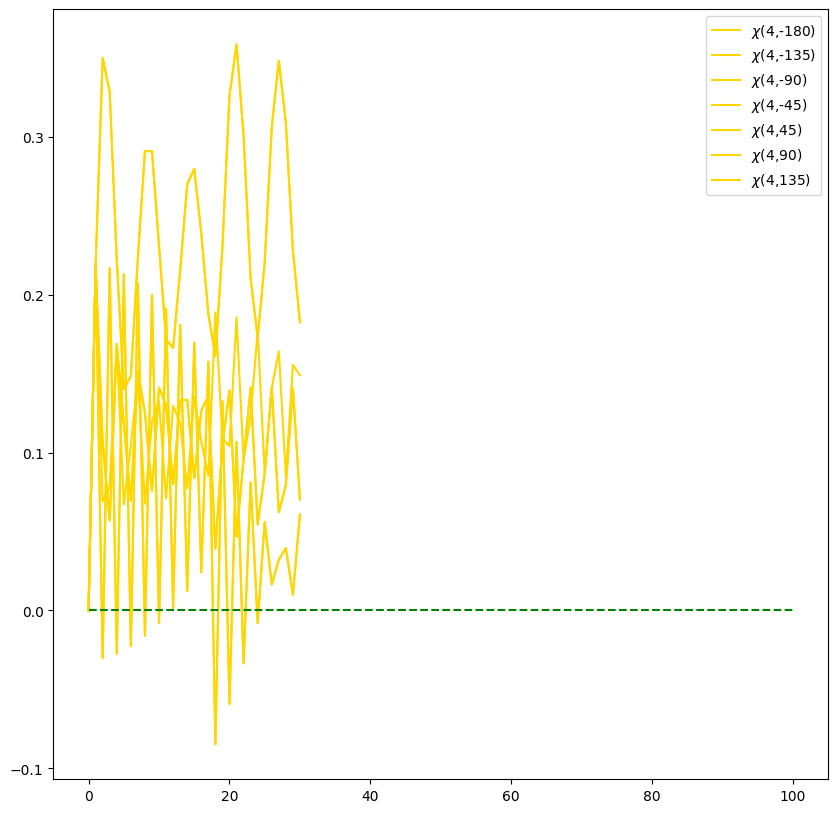

In [ ]:
# Because of the nature of the X_l term, for small epsilon stuff keeps breaking after many iterations. The purpose of this cell is
# to figure out exactly what is breaking so I can fix it.

def test_Chi(theta, n=25):
  print("Theta = ", theta, ", num iters = ", n)
  for rho in range(5):
    print(f"Chi({rho}, {theta}, {n}): ", Chi(rho, theta, n))
  print("\n")

angle_colors = {
    -180: "brown",
    -135: "red",
    -90: "orange",
    -45: "yellow",
    0: "green",
    45: "blue",
    90: "purple",
    135: "pink",
}

radius_colors = {
    1: "brown",
    2: "red",
    3: "orange",
    4: "gold",
    5: "yellow",
}

def plot_convergence(rho, theta, max_iters):
  n = np.arange(0, max_iters+1, 1, dtype=int)
  Chi_vals = np.array([])
  for l in range(max_iters+1):
    Chi_vals = np.append(Chi_vals, Chi(rho, theta, l))
  if Chi_vals[-1] < 0.0:
    print(f"Warning: $\\chi$({rho},{theta}) = {Chi_vals[-1]} < 0 after {l} iterations")
  # else:
    # print(f"$\\chi$({rho},{theta}) converged to f{Chi_vals[-1]} after {l} iterations")
  plt.plot(n, Chi_vals, label=f"$\\chi$({rho},{theta})", color=radius_colors[rho])

epsilon_colors = {
    # 0.00001: "pink",
    # 0.0001: "black",
    0.001: "brown",
    0.01: "red",
    0.1: "orange",
    1: "gold",
    10: "yellow",
    100: "green",
    # 1000: "blue"
}

def plot_convergence_front_back(max_iters, front):
  if front:
    Chi_fnc = Chi_front
  else:
    Chi_fnc = Chi_back
  n = np.arange(0, max_iters+1, 1, dtype=int)
  Chi_vals = np.array([])
  for l in range(max_iters+1):
    Chi_vals = np.append(Chi_vals, Chi_fnc(l))
    if Chi_vals[-1] == np.nan:
      print(f"Warning: $\\chi_{{F}}$ = {Chi_vals[-1]} after {l} iterations")
      continue
  if Chi_vals[-1] < 0.0:
    print(f"Warning: $\\chi_{{F}}$ = {Chi_vals[-1]} < 0 after {l} iterations")
  # else:
    # print(f"$\\chi$({rho},{theta}) converged to f{Chi_vals[-1]} after {l} iterations")
  label = "F" if front else "B"
  plt.plot(n, Chi_vals, label=f"$\\chi_{label}$ at $\\varepsilon={epsilon}$", color=epsilon_colors[epsilon])

def compare_convergences_front_back(iters):
  for eps_val, color in epsilon_colors.items():
    set_epsilon(eps_val)
    plot_convergence_front_back(iters, True)
    plot_convergence_front_back(iters, False)

  plt.gcf().set_size_inches(10, 10)
  plt.plot(np.arange(0, iters+1, 1), np.zeros(iters+1), color="green", linestyle="--")
  plt.legend()
  plt.show()

def compare_convergences(eps_val, rho_min, rho_max, theta_min, theta_max, iters):
  set_epsilon(eps_val)
  for theta in range(theta_min, theta_max+1, 45):
    for rho in range(rho_min, rho_max+1):
      if rho is not 4: continue
      if is_near_pole(rho, theta): continue
      plot_convergence(rho, theta, iters)

  # plt.legend()
  plt.gcf().set_size_inches(10, 10)
  plt.plot(np.arange(0, iters+1, 1), np.zeros(iters+1), color="green", linestyle="--")
  plt.legend()
  plt.show()

compare_convergences(0.0001, 1, 5, -180, 179, 100)
# compare_convergences_front_back(10)
# compare_convergences(0.5, 50)
# compare_convergences(0.1, 50)
# compare_convergences(0.01, 50)

In [ ]:
def plot_chi_heatmap (x_bounds, z_bounds, cell_size, ax, iters=25, chi_debug=False):
  x, z = np.meshgrid(np.arange(x_bounds[0], x_bounds[1], cell_size), np.arange(z_bounds[0], z_bounds[1], cell_size))
  # doing normal np.atan(x / z) produces incorrect plot due to not picking the quadrants correctly
  chi = Chi(np.sqrt(z ** 2 + x ** 2), np.atan2(x, z), iters, chi_debug)
  img = ax.imshow(chi, extent=[x_bounds[0],x_bounds[1],z_bounds[0],z_bounds[1]], cmap="YlOrBr", origin='lower')
  ax.set_xlabel("x", fontsize="x-large")
  ax.set_ylabel("z", fontsize="x-large")
  ax.set_xticks([x_bounds[0], 0, x_bounds[1]])
  ax.set_yticks([z_bounds[0], 0, z_bounds[1]])
  ax.tick_params(labelsize="x-large")
  ax.set_title("$\\chi(\\lambda,\\theta)$", pad=10)
  return img

# Important: only works for cell sizes with one sig fig
# Also a lot slower, only use this version if you really need it
def plot_chi_heatmap_debug (x_bounds, z_bounds, num_cells_per_side, ax, iters=25, chi_debug=False):
  x_vals, z_vals = np.meshgrid( np.arange(x_bounds[0], x_bounds[1], (x_bounds[1] - x_bounds[0]) / num_cells_per_side),
                                np.arange(z_bounds[0], z_bounds[1], (z_bounds[1] - z_bounds[0]) / num_cells_per_side) )
  chis = []

  for z in z_vals[:, 0]:
    row = np.array([])
    for x in x_vals[0]:
      rho = np.sqrt( z**2 + x**2 )
      theta = np.atan2(x, z)
      chi = Chi(rho, theta, iters,  chi_debug)
      if chi < 0.0:
        print(f"Warning: $\\chi({rho}, {theta}) = {chi} < 0 after {iters} iterations)")
        chi = 0.0
      row = np.append(row, chi)
    chis.append(row)
    print(f"All chi values at z={z} found")

  img = ax.imshow(np.asarray(chis), extent=[x_bounds[0],x_bounds[1],z_bounds[0],z_bounds[1]], cmap="YlOrBr", origin='lower')
  ax.set_xlabel("x", fontsize="x-large")
  ax.set_ylabel("z", fontsize="x-large")
  ax.set_xticks([x_bounds[0], 0, x_bounds[1]])
  ax.set_yticks([z_bounds[0], 0, z_bounds[1]])
  ax.tick_params(labelsize="x-large")
  ax.set_title(f"$\\beta={beta}$, $\\varepsilon={epsilon}$", pad=10)
  return img

0.01
0
0.04
0.02
All chi values at z=-4.0 found
All chi values at z=-3.9 found
All chi values at z=-3.8 found
All chi values at z=-3.6999999999999997 found
All chi values at z=-3.5999999999999996 found
All chi values at z=-3.4999999999999996 found
All chi values at z=-3.3999999999999995 found
All chi values at z=-3.2999999999999994 found
All chi values at z=-3.1999999999999993 found
All chi values at z=-3.099999999999999 found
All chi values at z=-2.999999999999999 found
All chi values at z=-2.899999999999999 found
All chi values at z=-2.799999999999999 found
All chi values at z=-2.699999999999999 found
All chi values at z=-2.5999999999999988 found
All chi values at z=-2.4999999999999987 found
All chi values at z=-2.3999999999999986 found
All chi values at z=-2.2999999999999985 found
All chi values at z=-2.1999999999999984 found
All chi values at z=-2.0999999999999983 found
All chi values at z=-1.9999999999999982 found
All chi values at z=-1.8999999999999981 found
All chi values at z=-

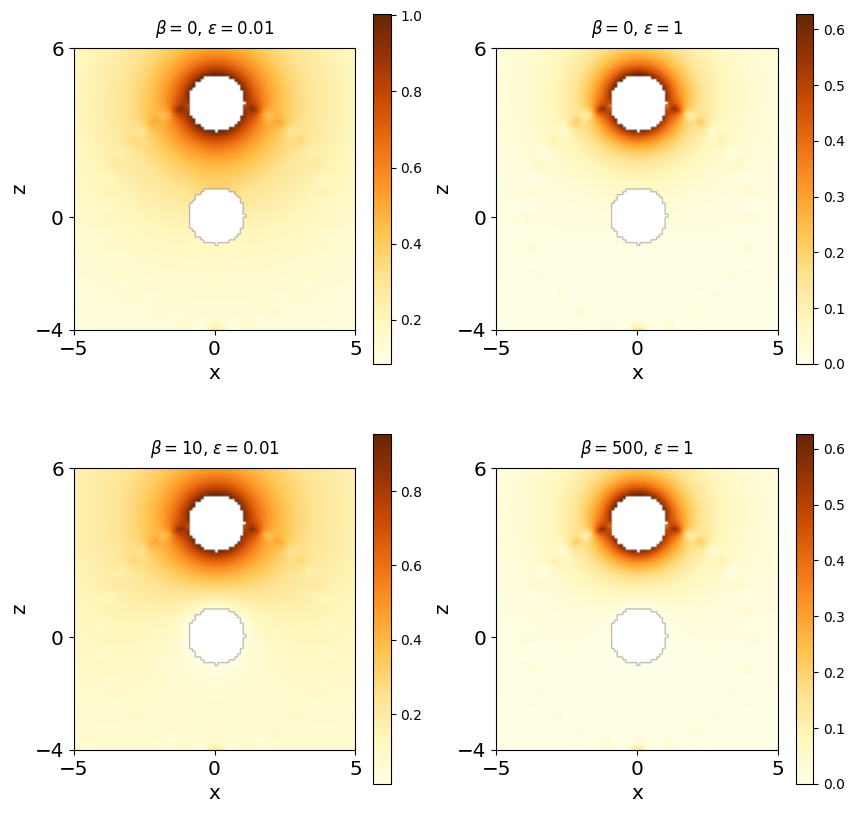

In [ ]:
x_bounds = [-5, 5]
z_bounds = [-4, 6]
cells_per_side = 100

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)

set_epsilon(0.01)
set_beta(0)
print(epsilon)
print(beta)
print(arg_0)
print(arg_e)
img1 = plot_chi_heatmap_debug(x_bounds, z_bounds, cells_per_side, ax1)
fig.colorbar(img1, ax=ax1)

set_epsilon(1)
set_beta(0)
print(epsilon)
print(beta)
print(arg_0)
print(arg_e)
img2 = plot_chi_heatmap_debug(x_bounds, z_bounds, cells_per_side, ax2)
fig.colorbar(img2, ax=ax2)

set_epsilon(0.01)
set_beta(10)
print(epsilon)
print(beta)
print(arg_0)
print(arg_e)
img3 = plot_chi_heatmap_debug(x_bounds, z_bounds, cells_per_side, ax3)
fig.colorbar(img3, ax=ax3)

set_epsilon(1)
set_beta(500)
print(epsilon)
print(beta)
print(arg_0)
print(arg_e)
img4 = plot_chi_heatmap_debug(x_bounds, z_bounds, cells_per_side, ax4)
fig.colorbar(img4, ax=ax4)

# fig.suptitle("$\\chi(\\lambda,\\theta)$ for different values of $\\beta$ and $\\varepsilon$")
fig.set_size_inches(10, 10)

# TODO: Examine expressions for epsilon and beta, compare with papers and see if their effects should really be differing by two orders of magnitude




0.01
0
0.04
0.02
1
0
4.0
2
0.01
10
0.04
0.02
1
500
4.0
2


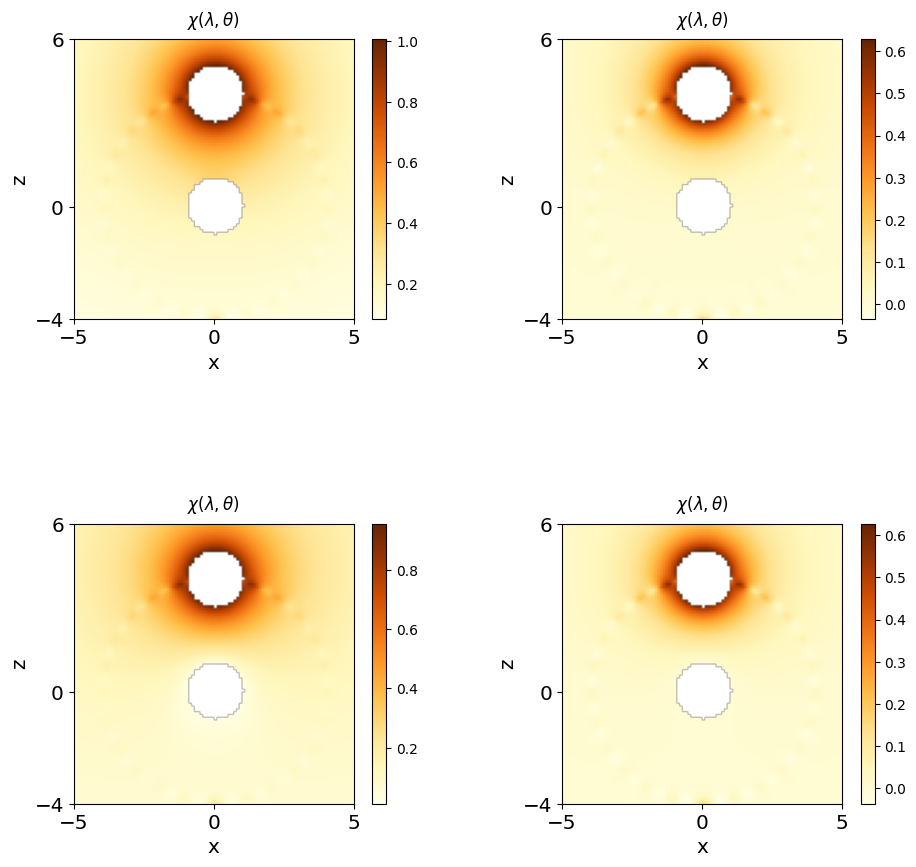

In [ ]:
x_bounds = [-5, 5]
z_bounds = [-4, 6]
cell_size = 0.1

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)

set_epsilon(0.01)
set_beta(0)
print(epsilon)
print(beta)
print(arg_0)
print(arg_e)
img1 = plot_chi_heatmap(x_bounds, z_bounds, cell_size, ax1)
fig.colorbar(img1, ax=ax1)

set_epsilon(1)
set_beta(0)
print(epsilon)
print(beta)
print(arg_0)
print(arg_e)
img2 = plot_chi_heatmap(x_bounds, z_bounds, cell_size, ax2)
fig.colorbar(img2, ax=ax2)

set_epsilon(0.01)
set_beta(10)
print(epsilon)
print(beta)
print(arg_0)
print(arg_e)
img3 = plot_chi_heatmap(x_bounds, z_bounds, cell_size, ax3)
fig.colorbar(img3, ax=ax3)

set_epsilon(1)
set_beta(500)
print(epsilon)
print(beta)
print(arg_0)
print(arg_e)
img4 = plot_chi_heatmap(x_bounds, z_bounds, cell_size, ax4)
fig.colorbar(img4, ax=ax4)

plt.tight_layout()
fig.set_size_inches(10, 10)

In [ ]:
GREEK_LETTERS = {
    "alpha":   ("α", "Α"),
    "beta":    ("β", "Β"),
    "gamma":   ("γ", "Γ"),
    "delta":   ("δ", "Δ"),
    "epsilon": ("ε", "Ε"),
    "zeta":    ("ζ", "Ζ"),
    "eta":     ("η", "Η"),
    "theta":   ("θ", "Θ"),
    "iota":    ("ι", "Ι"),
    "kappa":   ("κ", "Κ"),
    "lambda":  ("λ", "Λ"),
    "mu":      ("μ", "Μ"),
    "nu":      ("ν", "Ν"),
    "xi":      ("ξ", "Ξ"),
    "omicron": ("ο", "Ο"),
    "pi":      ("π", "Π"),
    "rho":     ("ρ", "Ρ"),
    "sigma":   ("σ", "Σ"),
    "tau":     ("τ", "Τ"),
    "upsilon": ("υ", "Υ"),
    "phi":     ("φ", "Φ"),
    "chi":     ("χ", "Χ"),
    "psi":     ("ψ", "Ψ"),
    "omega":   ("ω", "Ω"),
}


def greek(s: str) -> str:
    """Convert a romanized Greek letter name to its Unicode symbol.

    Capitalization rules:
        - ALL CAPS  (e.g. "ALPHA") → uppercase Greek letter (Α)
        - Title case (e.g. "Alpha") → uppercase Greek letter (Α)
        - Anything else (e.g. "alpha") → lowercase Greek letter (α)

    Returns None if the string is not a recognized Greek letter name.
    """
    key = s.strip().lower()
    if key not in GREEK_LETTERS:
        return key

    lower, upper = GREEK_LETTERS[key]
    if s.isupper() or (s[0].isupper() and s[1:].islower()):
        return upper
    return lower

In [ ]:
def plot_metric_heatmap (metric_name="output", metric_fnc=output, beta_max=5, eps_max=5, num_cells_per_side=25, ax=None, show_max=False, **kwargs):
  # eps_max_fake = eps_max
  # if sqrt_eps: eps_max_fake = eps_max ** 2
  beta_vals, eps_vals = np.meshgrid(np.arange(0, beta_max, beta_max / num_cells_per_side), np.arange(0, eps_max, eps_max / num_cells_per_side))
  # if sqrt_eps: eps_vals = eps_vals ** 2
  # print(beta_vals)
  # print(eps_vals)
  # print(beta_vals[:, 0])
  # print(eps_vals[0])
  vals = []
  max_val = 0
  max_beta = 0
  max_eps = 0
  for eps_val in eps_vals[:, 0]:
    row = np.array([])
    for beta_val in beta_vals[0]:
      set_epsilon(eps_val)
      set_beta(beta_val)
      val = metric_fnc(**kwargs)
      # print(val)
      if val > max_val:
        max_beta = beta_val
        max_eps = eps_val
        max_val = val
      row = np.append(row, val)
    vals.append(row)

  img = ax.imshow(np.asarray(vals), extent=[0, beta_max, 0, eps_max], cmap="YlOrBr", origin='lower')
  print(f"Max {metric_name} = ({max_val}), reached at epsilon = {max_eps}, beta = {max_beta}")
  if show_max:
    ax.plot(max_beta, max_eps, 'x')
  ax.set_xlabel("$\\beta$", fontsize="x-large")
  # label = "$\\sqrt{{\\varepsilon}}$" if sqrt_eps else "$\\varepsilon$"
  ax.set_ylabel("$\\varepsilon$", fontsize="x-large")
  ax.set_xticks([0, beta_max])
  ax.set_yticks([0, eps_max])
  ax.tick_params(labelsize="x-large")
  ax.set_title(metric_name, pad=10)
  ax.set_aspect(max(beta_max, eps_max) / min(beta_max, eps_max))
  return img


0.20032924042975778
0.21033436857961943
0.21042069135154476
0.20676057344708243
0.20168750504102603
0.19617570459607211
0.19065452551763054
0.18531488436414154
0.1802369578908642
0.17544762007258505
0.2631948210474027
0.2550526912348415
0.24470777349190978
0.23439985573196742
0.22477075379096173
0.2159656764509025
0.2079655126873864
0.20069950154847876
0.19408578338333354
0.18804598505891904
0.23146219519080163
0.2171155698092732
0.20470645881284807
0.19401413987399788
0.18474267797997923
0.17663208155206228
0.16947298776686262
0.16310039927452272
0.1573844056939613
0.15222204504354953
0.16331347152875073
0.15255962463839548
0.14362188407611712
0.13606226958653428
0.12956874737200869
0.12391655754475804
0.11894063610416639
0.11451725459238753
0.11055185795700295
0.10697090155272308
0.10548476259108569
0.09892059375967802
0.09344135014498658
0.08878044750399963
0.08475369939696023
0.08122971424426594
0.07811209929991383
0.07532840167627719
0.0728230064738101
0.07055243603347958
0.065632

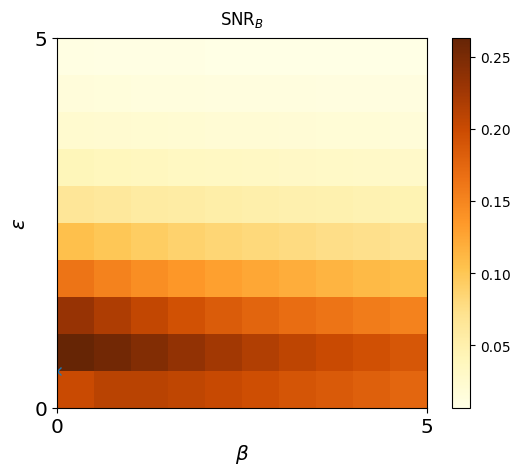

In [ ]:
set_kappa(1)
ax = plt.gca()
img = plot_metric_heatmap("SNR$_B$", bound_SNR, 5, 2, 5, ax, True)
fig = plt.gcf()
fig.colorbar(img, ax=ax)
plt.show()

Max Anisotropy = (0.8111866974019777), reached at epsilon = 4.800000000000001, beta = 4.800000000000001


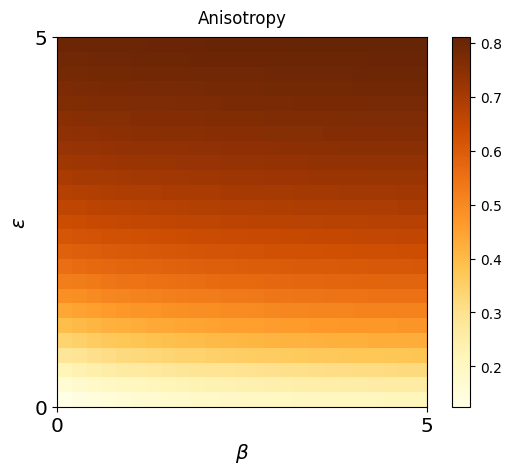

In [ ]:
ax = plt.gca()
img = plot_metric_heatmap("Anisotropy", Anisotropy, 5, 5, 25, ax)
fig = plt.gcf()
fig.colorbar(img, ax=ax)
plt.show()

# Ok, issues:
# - When epsilon is at all greater than 0, the effects of beta are so small as to be negligible.
#   TODO: Try scaling epsilon down and see if the division is just as sharp.
#   It is! This is really bad. This might mean the effects of beta are not scaling properly at all.
# - Also, when epsilon is 0, the value is still just undefined.

# Ok, by adding in the limiting cases separately when epsilon is within 1e-05 of 0 Chi is now defined for all values of epsilon.
# The problem remains this disparity between the scales of epsilon and beta.

# Ok, actually this is fixed now by setting the beta max to a reasonable amount. Basically epsilon is 100x as potent as beta.
# One wonders what the physical meaning of this could be.
# Maybe epsilon is just much more effective at increasing anisotropy. That could be our answer right there.
# Are epsilon and beta on "equal footing"?
# Besides their common factors, epsilon scales with the cell radius (which I think we are assuming doesn't change), the rate of release of degrading enzyme,
# and the rate of degradation when enzyme contacts pheromone anywhere in 3D space, while it scales inversely with the diffusion of the enzyme.
# Besides their common factors, beta is actually inversely proportional to cell radius (again, I think we leave this alone),
# while it is proportional to the rate of removal of the pheromone at the detector surface.
# So, it's totally reasonable that epsilon and beta are on equal footing, but then idk how I would assign a cost to it. We'd probably have to assign a cost
# to each of the original parameters and use that to determine the cost of increasing beta or epsilon.

# (Sidenote: When (eps, beta) = (0, 0), Anisotropy is still > 0, which is good.)

# Note 5/18/26: I could see a world where cell radius actually plays a factor if the cell separation were to increase/decrease.

In [ ]:
print(rho_0)

4


Max SNR_B = (0.13477756901295143), reached at beta = 5.0


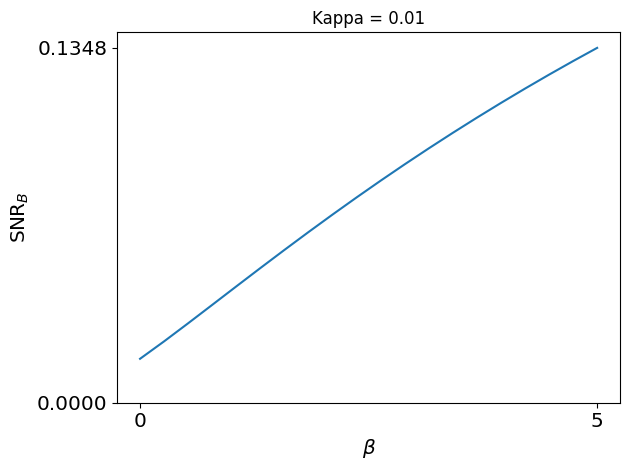

Max SNR_B = (0.2850807031860182), reached at beta = 5.0


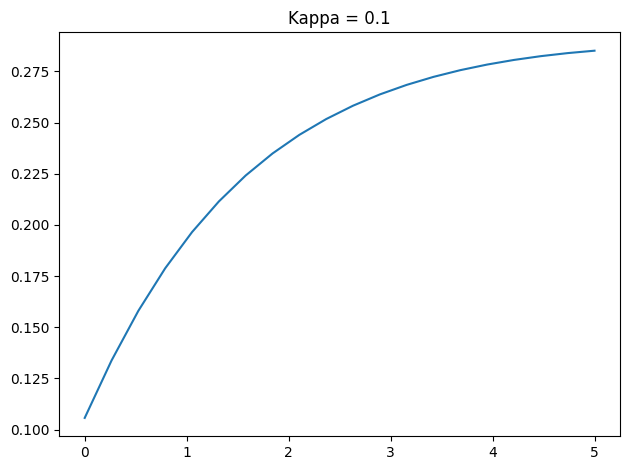

Max SNR_B = (0.17359783934849718), reached at beta = 1.0526315789473684


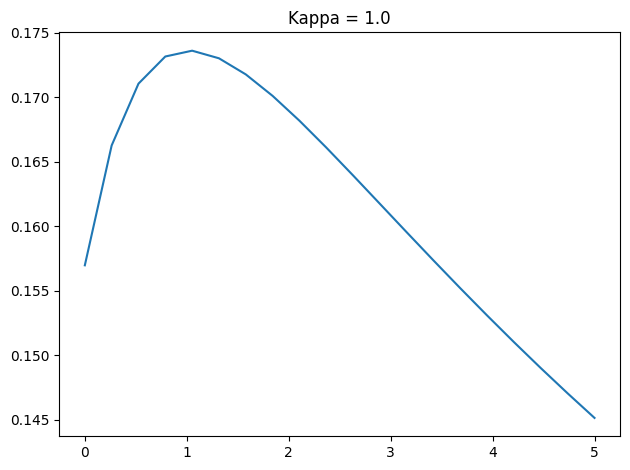

Max SNR_B = (0.06747568190478076), reached at beta = 0.2631578947368421


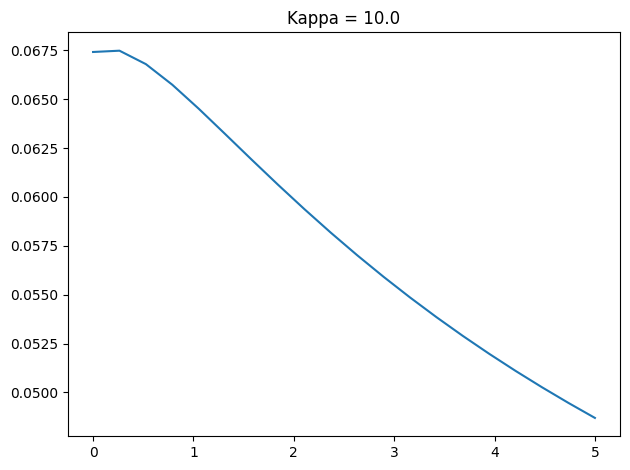

In [ ]:
beta_vals = np.linspace(0, 5, 20)
kappa_vals = np.logspace(-2, 1, 4)
set_epsilon(0)
set_alpha(1)
set_B0(1)
ax = plt.gca()
for kappa_val in kappa_vals:
  set_kappa(kappa_val)
  row = np.array([])
  max_beta = 0
  max_val = 0
  for beta_val in beta_vals:
    set_beta(beta_val)
    val = bound_SNR()
    # print(val)
    if val > max_val:
      max_beta = beta_val
      max_val = val
    row = np.append(row, val)
  print(f"Max SNR_B = ({max_val}), reached at beta = {max_beta}")
  plt.plot(beta_vals, row)
  plt.title(f"Kappa = {kappa}")
  ax.set_xticks([0, max_beta])
  ax.set_yticks([0, max_val])
  ax.set_xlabel("$\\beta$", fontsize="x-large")
  # label = "$\\sqrt{{\\varepsilon}}$" if sqrt_eps else "$\\varepsilon$"
  ax.set_ylabel("SNR$_B$", fontsize="x-large")
  ax.tick_params(labelsize="x-large")
  plt.tight_layout()
  plt.show()



Max SNR_B = (0.7384193645170046), reached at epsilon = 1.8421052631578947


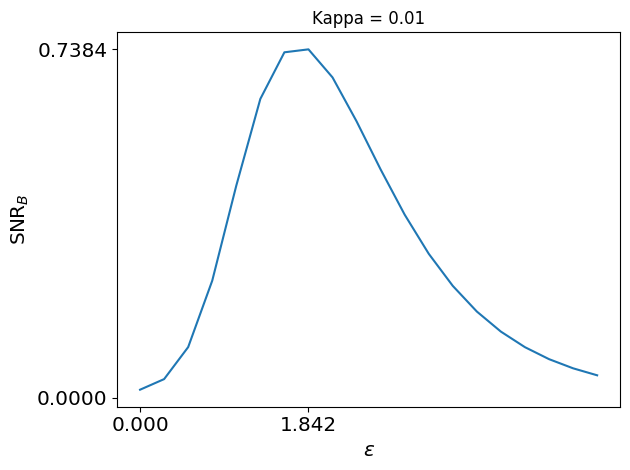

Max SNR_B = (0.4920750462734394), reached at epsilon = 1.0526315789473684


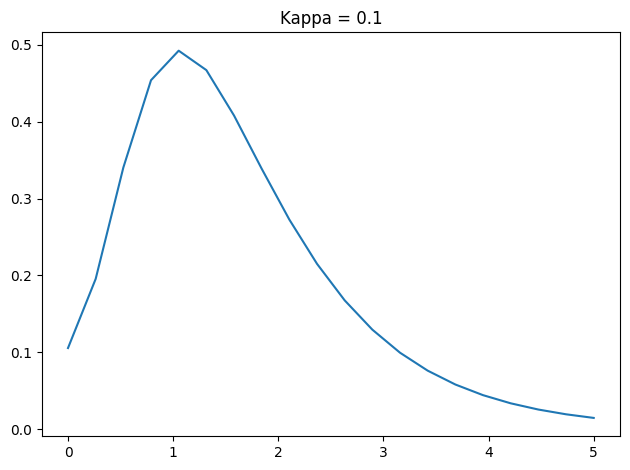

Max SNR_B = (0.22986214960745513), reached at epsilon = 0.5263157894736842


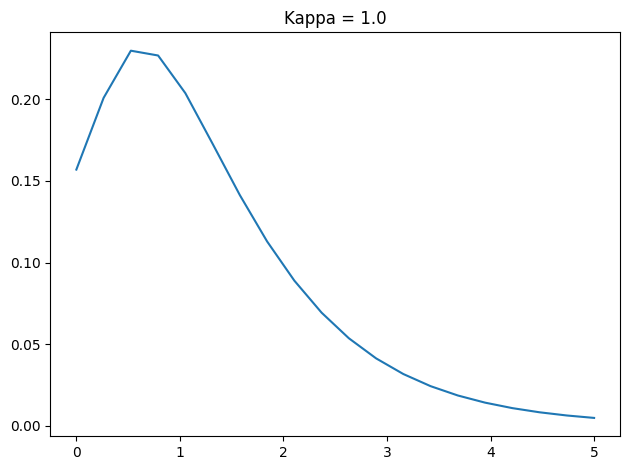

Max SNR_B = (0.08114893070262715), reached at epsilon = 0.5263157894736842


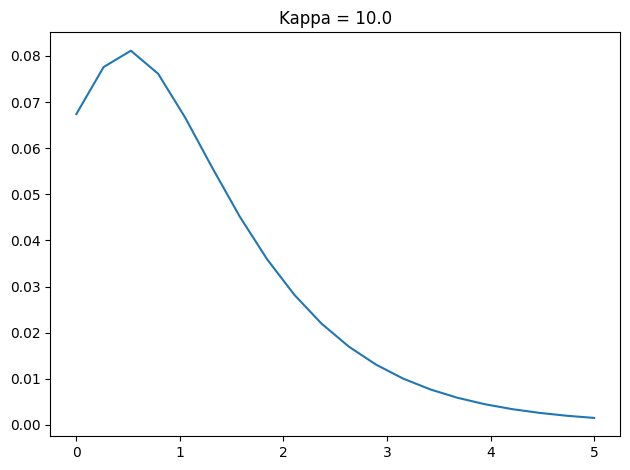

In [ ]:
eps_vals = np.linspace(0, 5, 20)
kappa_vals = np.logspace(-2, 1, 4)
set_beta(0)
set_alpha(1)
set_B0(1)
ax = plt.gca()
for kappa_val in kappa_vals:
  set_kappa(kappa_val)
  row = np.array([])
  max_eps = 0
  max_val = 0
  for eps_val in eps_vals:
    set_epsilon(eps_val)
    val = bound_SNR()
    # print(val)
    if val > max_val:
      max_eps = eps_val
      max_val = val
    row = np.append(row, val)
  print(f"Max SNR_B = ({max_val}), reached at epsilon = {max_eps}")
  plt.plot(beta_vals, row)
  plt.title(f"Kappa = {kappa}")
  ax.set_xticks([0, max_eps])
  ax.set_yticks([0, max_val])
  ax.set_xlabel("$\\varepsilon$", fontsize="x-large")
  # label = "$\\sqrt{{\\varepsilon}}$" if sqrt_eps else "$\\varepsilon$"
  ax.set_ylabel("SNR$_B$", fontsize="x-large")
  ax.tick_params(labelsize="x-large")
  plt.tight_layout()
  plt.show()



In [ ]:
gammas = np.linspace(0, 1, 20)

B_colors = {
    0.0001: "pink",
    0.001: "black",
    0.01: "brown",
    0.1: "red",
    1.0: "orange",
    10.0: "gold",
    100.0: "yellow",
    1000.0: "green",
    10000.0: "blue",
    100000.0: "purple"
}

def plot_budget_curves(metric_name="output", metric_fnc=output, Bmin=0.01, Bmax=100, ax=None):
  B = Bmin
  while B <= Bmax:
    vals = np.array([])
    for gamma in gammas:
      set_beta(B*(1 - gamma))
      set_epsilon(B*gamma)
      vals = np.append(vals, metric_fnc())

    maximizer_index = np.argmax(vals)
    print(f"Max {metric_name} = ({vals[maximizer_index]}), reached at gamma = {gammas[maximizer_index]}")
    ax.plot(gammas, vals, color=B_colors[B], label=f"B={B}")
    B *= 10

  ax.set_xlabel("$\\gamma$", fontsize="x-large")
  ax.set_ylabel(metric_name, fontsize="x-large")
  ax.set_xticks([0, 1])
  ax.tick_params(labelsize="x-large")
  # ax.set_xlim(0.9, 1)
  # ax.set_title("Production Possibilities Frontier: $\\beta$ & $\\epsilon$", fontsize="xx-large", pad=10)
  ax.legend()

Max Anisotropy = (0.1256218905472637), reached at gamma = 0.0
Max Anisotropy = (0.1392361912631998), reached at gamma = 1.0
Max Anisotropy = (0.39230045024628923), reached at gamma = 1.0
Max Anisotropy = (0.9003834429626506), reached at gamma = 1.0
Max Anisotropy = (nan), reached at gamma = 0.894736842105263


/tmp/ipykernel_1391/1455125048.py:33: RuntimeWarning: overflow encountered in exp
  ratio    = np.exp(log_r) # keep for diagnostics
/tmp/ipykernel_1391/1455125048.py:36: RuntimeWarning: overflow encountered in exp
  inner = np.exp(log_r) * kve_sum + np.exp(2 * arg) * ive_sum
/tmp/ipykernel_1391/29621669.py:21: RuntimeWarning: invalid value encountered in scalar divide
  return R_l_lt(1, 1) / (R_l_lt(1, 0) * 3)


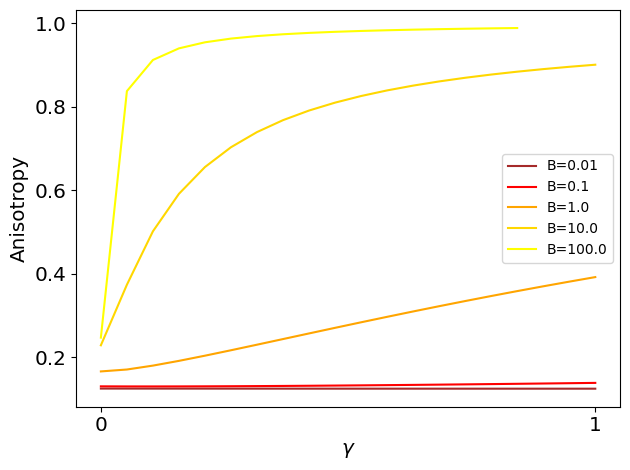

In [ ]:
plot_budget_curves("Anisotropy", Anisotropy, 0.01, 100, plt.gca())
plt.tight_layout()

Max $g_{ABS}$ = (3.1322655036779747), reached at gamma = 1.0
Max $g_{ABS}$ = (2.882262772681152), reached at gamma = 0.2631578947368421
Max $g_{ABS}$ = (1.5707963267948966), reached at gamma = 0.0
Max $g_{ABS}$ = (0.28559933214452676), reached at gamma = 0.0
Max $g_{ABS}$ = (0.03110487775831481), reached at gamma = 0.0


/tmp/ipykernel_1391/1455125048.py:33: RuntimeWarning: overflow encountered in exp
  ratio    = np.exp(log_r) # keep for diagnostics
/tmp/ipykernel_1391/1455125048.py:36: RuntimeWarning: overflow encountered in exp
  inner = np.exp(log_r) * kve_sum + np.exp(2 * arg) * ive_sum


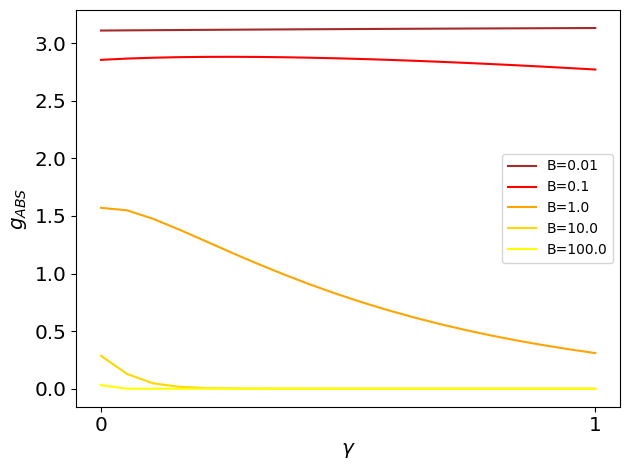

In [ ]:
plot_budget_curves("$g_{ABS}$", g_abs, 0.01, 100, plt.gca())
plt.tight_layout()

Max $g_{REL}$ = (2.632715820942238), reached at gamma = 1.0
Max $g_{REL}$ = (18673.925966798757), reached at gamma = 1.0
Max $g_{REL}$ = (0.4542822634724211), reached at gamma = 0.0
Max $g_{REL}$ = (0.5161126942506049), reached at gamma = 1.0


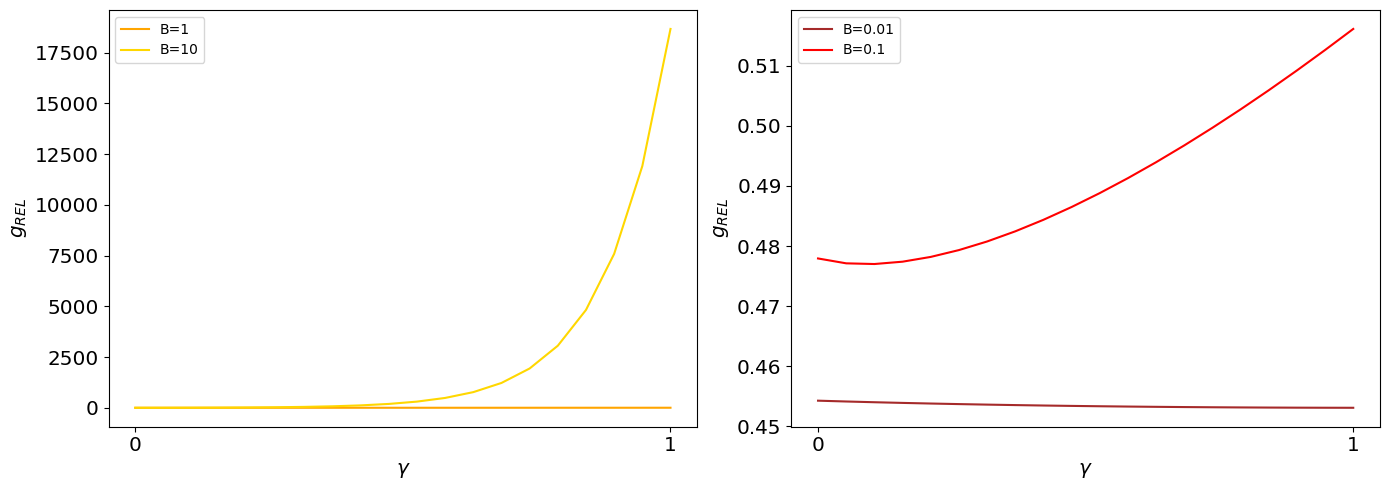

In [ ]:
# Note: Some precision is lost here as epsilon values below 1e-03 cause the radial function to bug out, so the limiting case must be used.
# Or, to be fair, I could try having less terms in the series for Chi_front and Chi_back.
# Update: Less terms doesn't seem to matter, as it converges really quickly for the epsilon values I'm interested in.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_budget_curves("$g_{REL}$", g_rel, 1, 10, ax1)
plot_budget_curves("$g_{REL}$", g_rel, 0.01, 0.1, ax2)
plt.tight_layout()


# Note: the weird artifacts are caused by switching over from the normal regime to the limiting case regime. I tried to make them as small as possible.
# Actually, it looks like for small enough limit tolerances, they disappear. This is nice. It's important to note that too small of a limit tolerance
# messes up the continuity at rho=rho_0 (perhaps because of the same phenomenon witnessed earlier where the series oscillates around the true value?),
# but is fine for other rho values not near rho_0, or at least "tolerable" (absolute error < 1e-05 in the worst case I found).

# Because epsilon is so OP, B=100 is not plotted as it leads to an overflow LMAO

In [ ]:
def plot_for_multiple_kappas(kappa_vals, plot_fnc, figsize=(14, 5), by_row=False, num_cols = None, **kwargs):
  if by_row:
    fig, axes = plt.subplots(len(kappa_vals), num_cols, figsize=figsize, sharey='row')
  else:
    fig, axes = plt.subplots(1, len(kappa_vals), figsize=figsize)
  for i in range(len(kappa_vals)):
    set_kappa(kappa_vals[i])
    print(kappa)
    ax = axes if len(kappa_vals) == 1 else axes[i]
    print(ax)
    img = plot_fnc(ax=ax, **kwargs)
    ax.set_title(f"$\\kappa={kappa}$")
    if plot_fnc == plot_metric_heatmap: fig.colorbar(img, ax=ax, fraction=0.1)


0.001
Axes(0.125,0.11;0.0945122x0.77)
Max SNR$_B$ = (0.9164066257153314), reached at epsilon = 2.0, beta = 4.0
0.01
Axes(0.238415,0.11;0.0945122x0.77)
Max SNR$_B$ = (0.7409213916802883), reached at epsilon = 1.5, beta = 1.0
0.05
Axes(0.351829,0.11;0.0945122x0.77)
Max SNR$_B$ = (0.5628265166829273), reached at epsilon = 1.0, beta = 1.0
0.1
Axes(0.465244,0.11;0.0945122x0.77)
Max SNR$_B$ = (0.4903718403330599), reached at epsilon = 1.0, beta = 0.0
0.5
Axes(0.578659,0.11;0.0945122x0.77)
Max SNR$_B$ = (0.287291868221576), reached at epsilon = 0.5, beta = 0.0
1
Axes(0.692073,0.11;0.0945122x0.77)
Max SNR$_B$ = (0.2285156189377758), reached at epsilon = 0.5, beta = 0.0
10
Axes(0.805488,0.11;0.0945122x0.77)
Max SNR$_B$ = (0.08123647749114603), reached at epsilon = 0.5, beta = 0.0


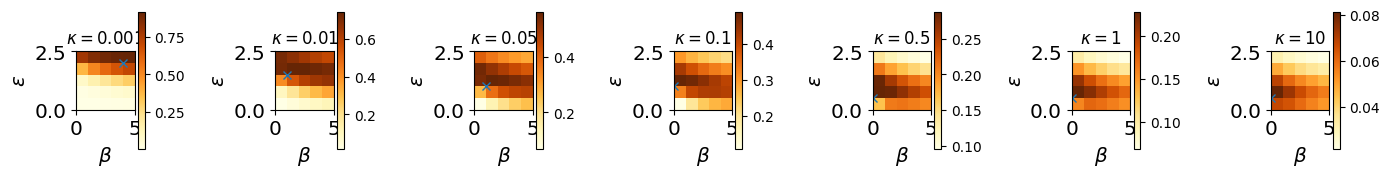

In [ ]:
plot_for_multiple_kappas([0.001, 0.01, 0.05, 0.1, 0.5, 1, 10], plot_metric_heatmap, beta_max=5, eps_max=2.5, metric_name="SNR$_B$", metric_fnc=bound_SNR, show_max=True, num_cells_per_side=5)
plt.tight_layout()

In [ ]:
plot_for_multiple_kappas([0.001, 0.01], plot_metric_heatmap, beta_max=10, eps_max=5, metric_name="SNR$_B$", metric_fnc=bound_SNR, show_max=True, num_cells_per_side=10)
plt.tight_layout()

0.001
Axes(0.125,0.11;0.352273x0.77)
Max SNR$_B$ = (0.9301544549531737), reached at epsilon = 2.5, beta = 0.0
0.01
Axes(0.547727,0.11;0.352273x0.77)


0.001
Axes(0.125,0.11;0.227941x0.77)
Max output = (0.00024614724459492976), reached at gamma = 0.0
Max output = (0.00030853216162696206), reached at gamma = 1.0
Max output = (0.01065775533801061), reached at gamma = 1.0
Max output = (0.6031037335795225), reached at gamma = 0.21052631578947367


/tmp/ipykernel_2411/1455125048.py:33: RuntimeWarning: overflow encountered in exp
  ratio    = np.exp(log_r) # keep for diagnostics
/tmp/ipykernel_2411/1455125048.py:36: RuntimeWarning: overflow encountered in exp
  inner = np.exp(log_r) * kve_sum + np.exp(2 * arg) * ive_sum
/tmp/ipykernel_2411/1455125048.py:36: RuntimeWarning: overflow encountered in scalar multiply
  inner = np.exp(log_r) * kve_sum + np.exp(2 * arg) * ive_sum


Max output = (0.04593362986086191), reached at gamma = 0.0
1
Axes(0.398529,0.11;0.227941x0.77)
Max output = (0.0893125439964586), reached at gamma = 0.0
Max output = (0.10131589691721665), reached at gamma = 1.0
Max output = (0.1673096140547856), reached at gamma = 0.5263157894736842
Max output = (0.07304667789378583), reached at gamma = 0.0
Max output = (0.010817144002210358), reached at gamma = 0.0
1000
Axes(0.672059,0.11;0.227941x0.77)
Max output = (0.0005767384886592197), reached at gamma = 1.0
Max output = (0.0005670223906447183), reached at gamma = 1.0
Max output = (0.0003905869453609841), reached at gamma = 0.10526315789473684
Max output = (9.520549724250469e-05), reached at gamma = 0.0
Max output = (1.1155542824065154e-05), reached at gamma = 0.0


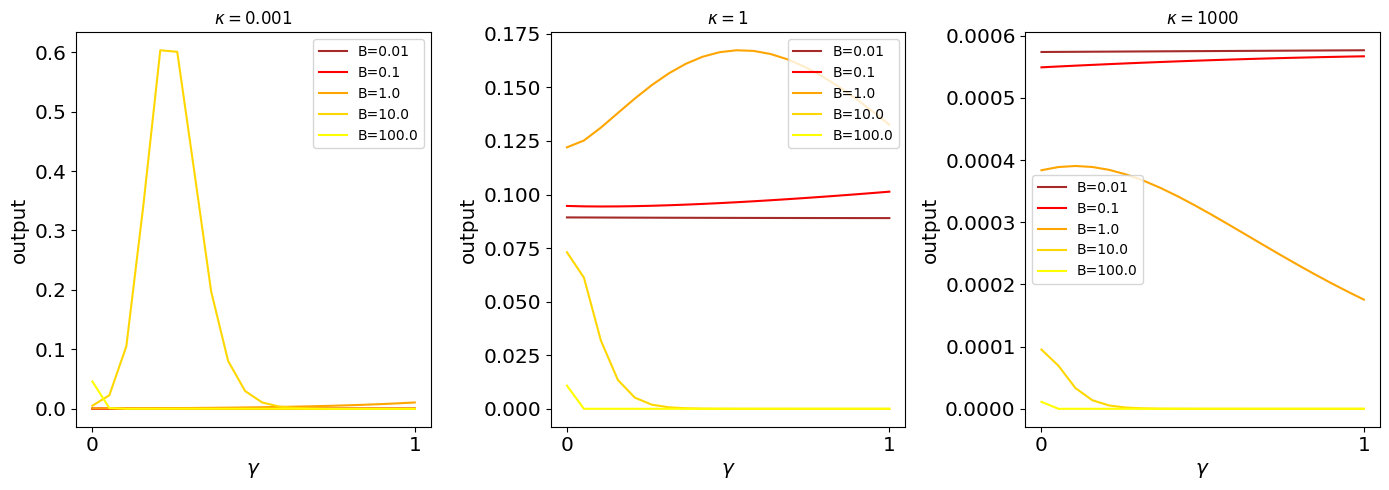

In [ ]:
plot_for_multiple_kappas([0.001, 1, 1000], plot_budget_curves)
plt.tight_layout()

# This is my take: The peaks for B=10 and B=100 on the kappa=0.001 graph are a feature, not a bug. You lowkey should get penalized
# if you degrade the signal to the point where you can't even sense it anymore.

0.001
Axes(0.125,0.11;0.227941x0.77)
Max output = (0.016701968015034208), reached at epsilon = 0.96, beta = 0.96
1
Axes(0.398529,0.11;0.227941x0.77)
Max output = (0.17364522095423074), reached at epsilon = 0.6, beta = 0.0
1000
Axes(0.672059,0.11;0.227941x0.77)
Max output = (0.000576835288342021), reached at epsilon = 0.0, beta = 0.0


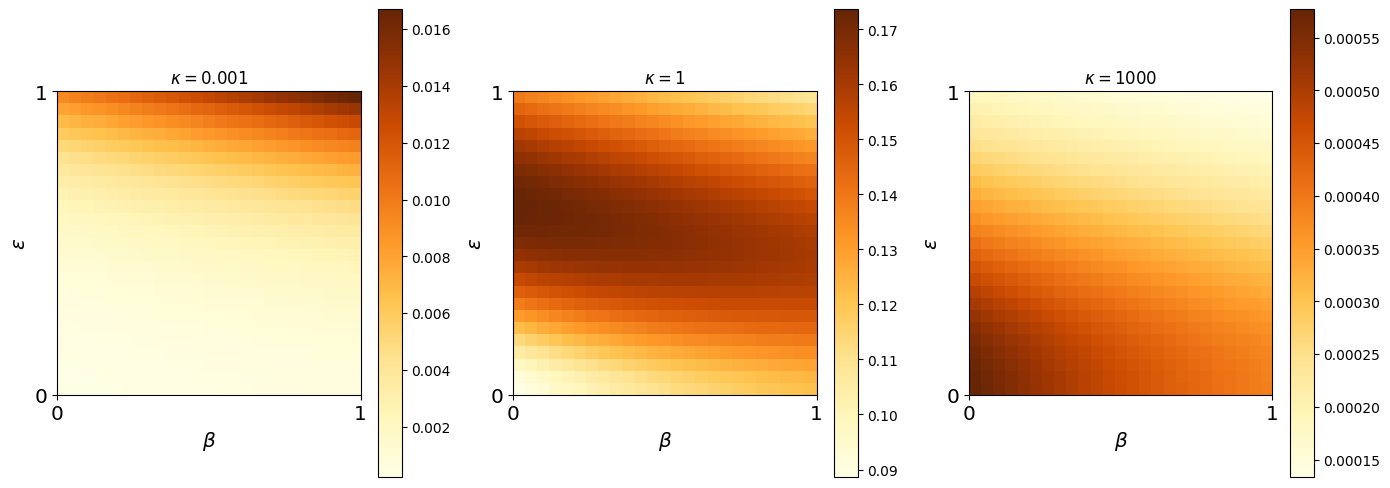

In [ ]:
plot_for_multiple_kappas([0.001, 1, 1000], plot_metric_heatmap, beta_max=1, eps_max=1)
plt.tight_layout()

0.001
Axes(0.125,0.11;0.775x0.77)
Max output = (0.6519349554631424), reached at epsilon = 2.7, beta = 1.55


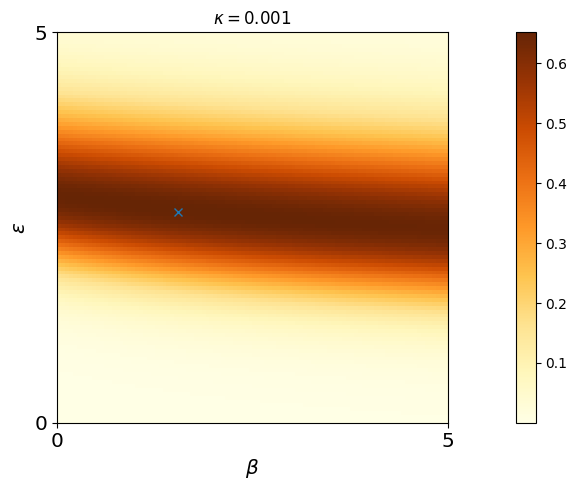

In [ ]:
plot_for_multiple_kappas([0.001], plot_metric_heatmap, num_cells_per_side=100, show_max=True)
plt.tight_layout()

0.001
Axes(0.125,0.11;0.775x0.77)
Max output = (0.6510170058111773), reached at epsilon = 2.8000000000000003, beta = 0.6000000000000001


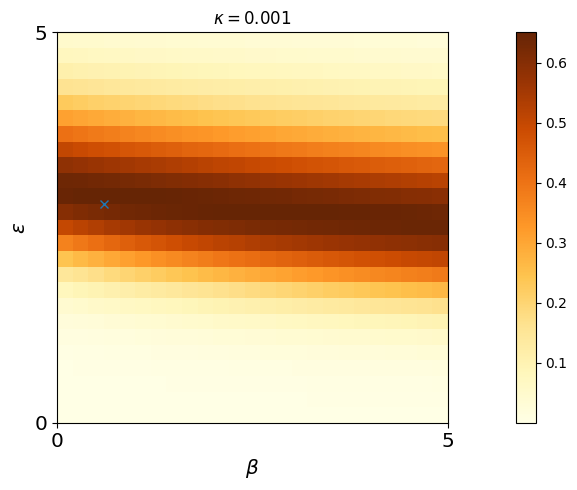

In [ ]:
plot_for_multiple_kappas([0.001], plot_metric_heatmap, show_max=True)
plt.tight_layout()

In [ ]:
print(kappa)

1


Max SNR = (0.30700282618775915), reached at epsilon = 0.4, beta = 0.0


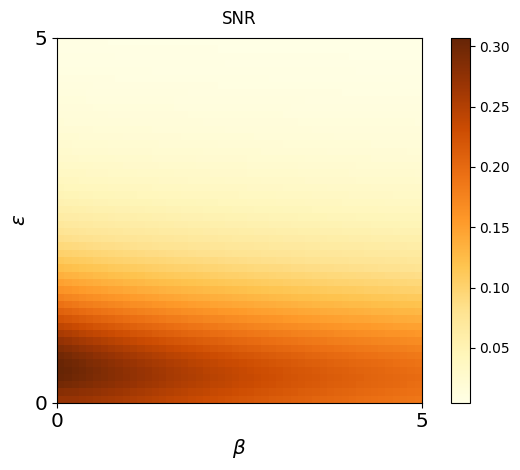

In [ ]:
ax = plt.gca()
img = plot_metric_heatmap("SNR", SNR, ax=ax, num_cells_per_side=50, use_avg=False)
fig = plt.gcf()
fig.colorbar(img, ax=ax)
plt.tight_layout()

Max SNR = (0.3819699914570387), reached at epsilon = 0.5, beta = 0.0


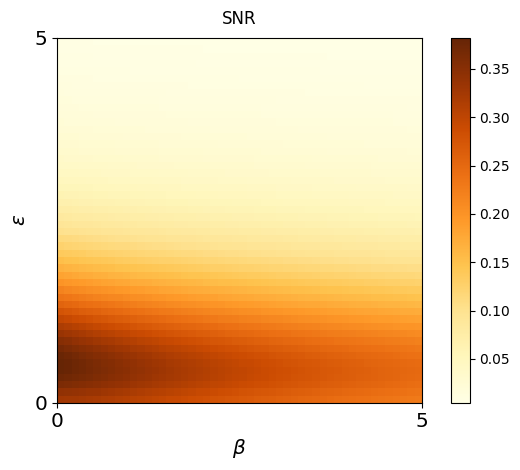

In [ ]:
ax = plt.gca()
img = plot_metric_heatmap("SNR", SNR, ax=ax, num_cells_per_side=50, use_avg=True)
fig = plt.gcf()
fig.colorbar(img, ax=ax)
plt.tight_layout()

Max New SNR = (0.22043455005487433), reached at epsilon = 0.5, beta = 0.0


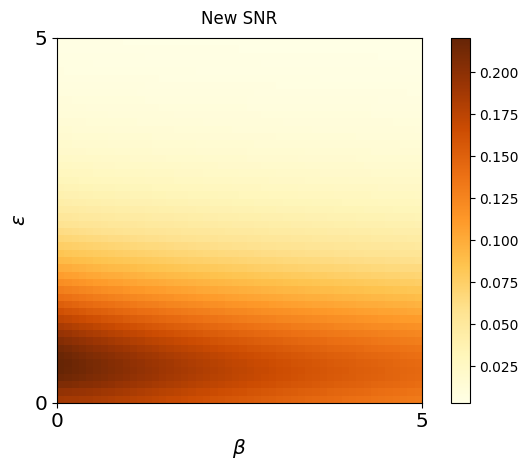

In [ ]:
ax = plt.gca()
img = plot_metric_heatmap("New SNR", new_SNR, num_cells_per_side=50, ax=ax)
fig = plt.gcf()
fig.colorbar(img, ax=ax)
plt.tight_layout()

/tmp/ipykernel_646/1222928187.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  return (6 * alpha) / (epsilon * rho_0) * k0(3) / (
/tmp/ipykernel_646/1222928187.py:41: RuntimeWarning: invalid value encountered in scalar multiply
  i0(3) * (k0(2) + k0(4)) +
/tmp/ipykernel_646/1222928187.py:42: RuntimeWarning: invalid value encountered in scalar multiply
  k0(3) * (i0(2) + i0(4))
/tmp/ipykernel_646/1222928187.py:56: RuntimeWarning: invalid value encountered in scalar multiply
  ke(3) + epsilon * (ke(2) + ke(4))
/tmp/ipykernel_646/1222928187.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  return (2 * alpha) / (epsilon * rho_0) * k0(1) / (
/tmp/ipykernel_646/1222928187.py:35: RuntimeWarning: invalid value encountered in scalar multiply
  i0(1) * (k0(0) + k0(2)) +
/tmp/ipykernel_646/1222928187.py:49: RuntimeWarning: invalid value encountered in scalar multiply
  ke(1) + epsilon * (ke(0) + ke(2))


Max New New New SNR = (0.22058374752805818), reached at epsilon = 0.45, beta = 0.0


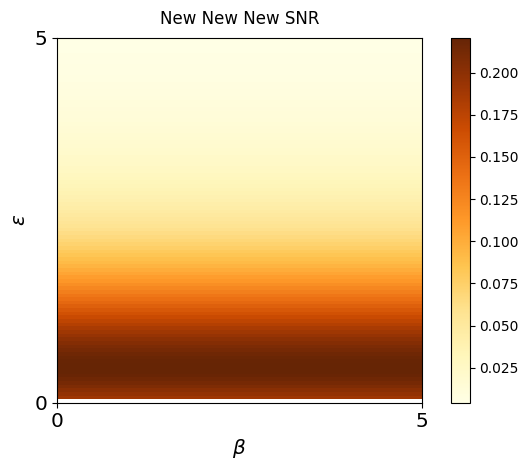

In [ ]:
ax = plt.gca()
img = plot_metric_heatmap("New New New SNR", new_new_new_SNR, num_cells_per_side=100, ax=ax)
fig = plt.gcf()
fig.colorbar(img, ax=ax)
plt.tight_layout()

Max SNR but it's actually $g_{REL}$ = (0.9999999990503117), reached at epsilon = 8.8, beta = 6.4


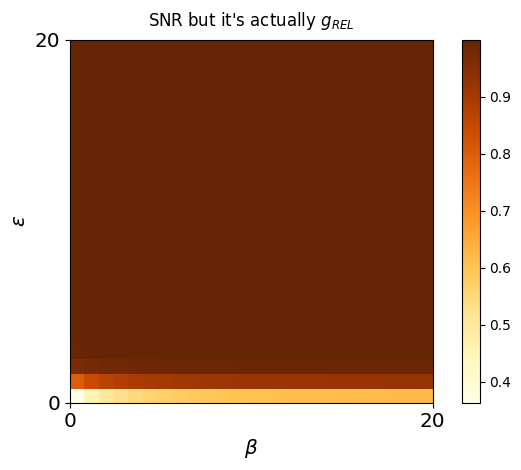

In [ ]:
ax = plt.gca()
img = plot_metric_heatmap("SNR but it's actually $g_{REL}$", fake_SNR, eps_max=20, beta_max=20, ax=ax)
fig = plt.gcf()
fig.colorbar(img, ax=ax)
plt.tight_layout()

Max $g_{ABS}$ = (3.141592653589793), reached at epsilon = 0.0, beta = 0.0


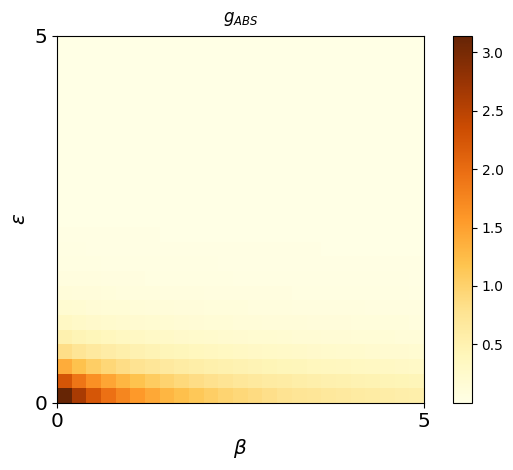

In [ ]:
ax = plt.gca()
img = plot_metric_heatmap("$g_{ABS}$", g_abs, ax=ax)
fig = plt.gcf()
fig.colorbar(img, ax=ax)
plt.tight_layout()

Max $g_{REL}$ = (15420919.1844991), reached at epsilon = 17.5, beta = 24.75


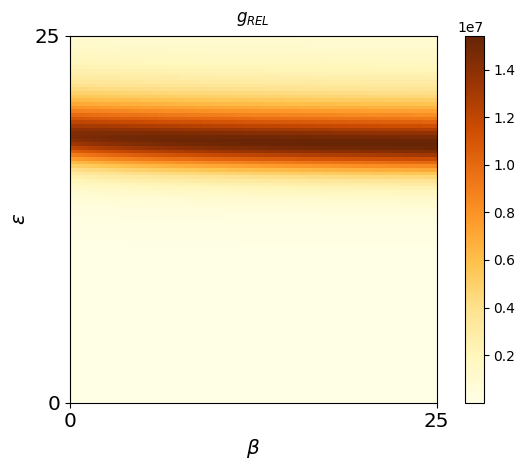

In [ ]:
ax = plt.gca()
img = plot_metric_heatmap("$g_{REL}$", g_rel, eps_max=25, beta_max=25, num_cells_per_side=100, ax=ax, show_max=True)
fig = plt.gcf()
fig.colorbar(img, ax=ax)
plt.tight_layout()

Max $g_{REL}$ = (14975743.401517013), reached at epsilon = 18.0, beta = 8.0


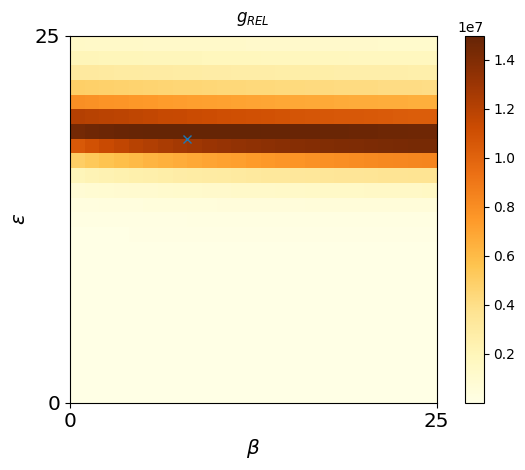

In [ ]:
ax = plt.gca()
img = plot_metric_heatmap("$g_{REL}$", g_rel, eps_max=25, beta_max=25, num_cells_per_side=25, ax=ax, show_max=True)
fig = plt.gcf()
fig.colorbar(img, ax=ax)
plt.tight_layout()

In [ ]:
param_bounds = [-2, 3]
kappa_bounds = [-3, 1]

def plot_output_heatmap (vs_beta, param_bounds, kappa_bounds, num_cells_per_side=25, ax=None, iters=25):
  param_vals, kappa_vals = np.meshgrid(
      np.arange(param_bounds[0], param_bounds[1] + np.abs(param_bounds[1] - param_bounds[0]) / num_cells_per_side, np.abs(param_bounds[1] - param_bounds[0]) / num_cells_per_side),
      np.arange(kappa_bounds[0], kappa_bounds[1] + np.abs(kappa_bounds[1] - kappa_bounds[0]) / num_cells_per_side, np.abs(kappa_bounds[1] - kappa_bounds[0]) / num_cells_per_side)
  )
  # print(beta_vals)
  # print(kappa_vals)
  print(param_vals[0])
  print(kappa_vals[:, 0])
  if vs_beta:
    set_epsilon(0)
  else:
    set_beta(0)

  output_vals = []
  for kappa_val in kappa_vals[:, 0]:
    row = np.array([])
    for param_val in param_vals[0]:
      set_kappa(10 ** kappa_val)
      if vs_beta:
        set_beta(10 ** param_val)
      else:
        set_epsilon(10 ** param_val)
      row = np.append(row, output(iters))
    # print(row)
    output_vals.append(row)
    # print(output_vals)

  Z = np.asarray(output_vals)
  # print(Z)
  # , extent=[beta_bounds[0], beta_bounds[1], kappa_bounds[0], kappa_bounds[1]], cmap="YlOrBr", origin='lower')
  cf = ax.contourf(param_vals, kappa_vals, Z, levels=np.linspace(Z.min(), Z.max(), 8), cmap="YlOrRd")
  label = "beta" if vs_beta else "varepsilon"
  ax.set_xlabel(f"$\\log_{{10}}\\{label}$", fontsize="x-large")
  ax.set_ylabel("$\\log_{10}\\kappa$", fontsize="x-large")
  ax.set_xticks([param_bounds[0], 0, param_bounds[1]])
  ax.set_yticks([kappa_bounds[0], -1, kappa_bounds[1]])
  # ax.set_xticks([-1, 1])
  # ax.set_yticks([-1, 1])
  # ax.set_xlim([-1, 1])
  # ax.set_ylim([-1, 1])
  ax.tick_params(labelsize="x-large")
  ax.set_title("output", pad=10)
  # ax.set_aspect(max(beta_bounds[1], kappa_bounds[1]) / min(beta_bounds[0], kappa_bounds[0]))
  return cf

In [ ]:
print(alpha)
set_alpha(10)

10


[-2.0000000e+00 -1.8000000e+00 -1.6000000e+00 -1.4000000e+00
 -1.2000000e+00 -1.0000000e+00 -8.0000000e-01 -6.0000000e-01
 -4.0000000e-01 -2.0000000e-01 -4.4408921e-16  2.0000000e-01
  4.0000000e-01  6.0000000e-01  8.0000000e-01  1.0000000e+00
  1.2000000e+00  1.4000000e+00  1.6000000e+00  1.8000000e+00
  2.0000000e+00  2.2000000e+00  2.4000000e+00  2.6000000e+00
  2.8000000e+00  3.0000000e+00]
[-3.   -2.84 -2.68 -2.52 -2.36 -2.2  -2.04 -1.88 -1.72 -1.56 -1.4  -1.24
 -1.08 -0.92 -0.76 -0.6  -0.44 -0.28 -0.12  0.04  0.2   0.36  0.52  0.68
  0.84  1.  ]


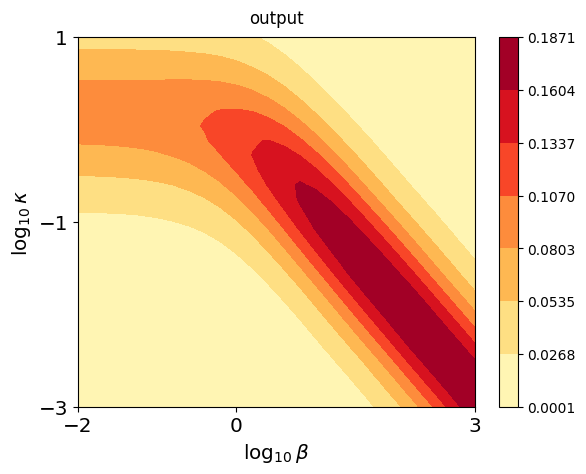

In [ ]:
set_alpha(1) # Trying to fix scaling discrepancy with their graph, just to make sure we're on even footing, unfortunately discrepancy is still present
cf = plot_output_heatmap(True, param_bounds, kappa_bounds, ax=plt.gca())
plt.gcf().colorbar(cf)

[-2.0000000e+00 -1.8000000e+00 -1.6000000e+00 -1.4000000e+00
 -1.2000000e+00 -1.0000000e+00 -8.0000000e-01 -6.0000000e-01
 -4.0000000e-01 -2.0000000e-01 -4.4408921e-16  2.0000000e-01
  4.0000000e-01  6.0000000e-01  8.0000000e-01  1.0000000e+00
  1.2000000e+00  1.4000000e+00  1.6000000e+00  1.8000000e+00
  2.0000000e+00  2.2000000e+00  2.4000000e+00  2.6000000e+00
  2.8000000e+00  3.0000000e+00]
[-3.   -2.84 -2.68 -2.52 -2.36 -2.2  -2.04 -1.88 -1.72 -1.56 -1.4  -1.24
 -1.08 -0.92 -0.76 -0.6  -0.44 -0.28 -0.12  0.04  0.2   0.36  0.52  0.68
  0.84  1.  ]


/tmp/ipykernel_2411/1455125048.py:33: RuntimeWarning: overflow encountered in exp
  ratio    = np.exp(log_r) # keep for diagnostics
/tmp/ipykernel_2411/1455125048.py:36: RuntimeWarning: overflow encountered in exp
  inner = np.exp(log_r) * kve_sum + np.exp(2 * arg) * ive_sum
/tmp/ipykernel_2411/1455125048.py:49: RuntimeWarning: overflow encountered in exp
  return prefactor * np.exp(arg) / inner
/tmp/ipykernel_2411/1455125048.py:49: RuntimeWarning: invalid value encountered in scalar divide
  return prefactor * np.exp(arg) / inner
/tmp/ipykernel_2411/1455125048.py:73: RuntimeWarning: overflow encountered in exp
  return -X_l(l) * ratio_nd * np.exp(2 * arg)
/tmp/ipykernel_2411/1455125048.py:94: RuntimeWarning: overflow encountered in exp
  return (X_l(l) * ive(order, arg) * np.exp(arg)


ValueError: lower_level and upper_level cannot be NaN

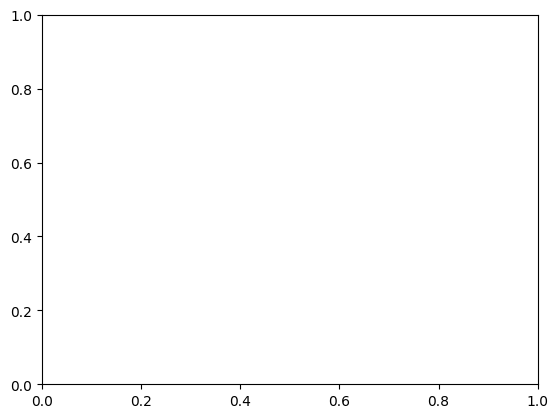

In [ ]:
cf = plot_output_heatmap(False, param_bounds, kappa_bounds, ax=plt.gca())
plt.gcf().colorbar(cf)

In [ ]:
from matplotlib.patches import ConnectionPatch

def plot_vs_isolated_params(metric_name="output", metric_fnc=output, enabled_params=(True, True), eps_max=100, beta_max=100, eps_min=0, beta_min=0, log_scale=False, width_factor=1, height_limit=None, line_offset=-0.15, axes=None, **kwargs):
  # fig, (ax1, ax2) = plt.subplots(1, 2)
  fig = plt.gcf()
  if axes == None:
    ax1 = plt.gca()
    ax2 = None
  elif len(axes) == 2:
    ax1 = axes[0]
    ax2 = axes[1]
  else:
    ax1 = axes[0]
    ax2 = None

  if enabled_params[0]:
    set_alpha(1)
    set_beta(0)

    if log_scale:
      eps_vals = np.array([])
      eps = eps_min
      while eps < eps_max:
        # print(f"Eps is now: {eps}")
        arr = np.linspace(eps, eps * 10, int(100 // eps))
        # print(arr)
        eps_vals = np.append(eps_vals, arr)
        eps *= 10
    else:
      eps_vals = np.linspace(eps_min, eps_max, 100)

    metric_vals = np.array([])
    max_val = 0.0
    max_eps_val = 0.0
    for eps_val in eps_vals:
      set_epsilon(eps_val)
      # print(f"Value appended at epsilon = {epsilon}")
      val = metric_fnc(**kwargs)
      if val > max_val:
        # print(f"new max val: {max_val}")
        max_val = val
        max_eps_val = epsilon
      metric_vals = np.append(metric_vals, val)
    print(f"Max {metric_name} = {max_val}, occurring at epsilon = {eps_vals[np.where(metric_vals == max_val)[0][0]]}")

    if log_scale:
      ax1.semilogx(eps_vals, metric_vals)
      ax1.set_xticks([0.01, 1, eps_max])
    else:
      ax1.plot(eps_vals, metric_vals)
      ax1.set_xticks([0, eps_max])
    ax1.set_xlabel("$\\epsilon$", fontsize="x-large")
    ax1.set_ylabel(metric_name, fontsize="x-large")
    # ax1.set_xticks([0.0, eps_max])
    ax1.set_yticks([0, np.round(max(metric_vals), 1)]) if height_limit == None else ax1.set_yticks([0, np.round(max(metric_vals), 1), height_limit])
    ax1.tick_params(labelsize="x-large")
    ax1.set_title(f"{metric_name} vs. $\\varepsilon$, $\\beta=0$", pad=10)
    # ax1.set_aspect(1.0/ax1.get_data_ratio(), adjustable='box')

  if enabled_params[1] and ax2 != None:
    set_alpha(1)
    set_epsilon(0)

    if log_scale:
      beta_vals = np.array([])
      beta = beta_min
      while beta < beta_max:
        beta_vals = np.append(beta_vals, np.linspace(beta, beta * 10, 10))
        beta *= 10
    else:
      beta_vals = np.linspace(beta_min, beta_max, 20)

    max_val = 0.0
    metric_vals = np.array([])
    for beta_val in beta_vals:
      set_beta(beta_val)
      # print(f"Value appended at epsilon = {epsilon}")
      val = metric_fnc(**kwargs)
      if val > max_val:
        max_val = val
      metric_vals = np.append(metric_vals, val)
    print(f"Max {metric_name} = {max_val}, occurring at beta = {np.where(metric_vals == max_val)}")

    if log_scale:
      ax2.semilogx(beta_vals, metric_vals)
      ax2.set_xticks([0.01, 1, beta_max])
    else:
      ax2.plot(beta_vals, metric_vals)
      ax2.set_xticks([0, beta_max])
    ax2.set_xlabel("$\\beta$", fontsize="x-large")
    ax2.tick_params(labelsize="x-large")

    # ax2.annotate(
    #   f"$\\kappa={kappa}$",
    #   xy=(1.02, 0.5),               # just outside the right edge, vertically centered
    #   xycoords="axes fraction",
    #   rotation=-90,                  # 90 degrees clockwise
    #   va="center",
    #   ha="left",
    #   fontsize="x-large",
    #   annotation_clip=False          # allows drawing outside the axes bounds
    # )
    ax2.set_title(f"{metric_name} vs. $\\beta$, $\\varepsilon=0$", pad=10)
    # ax2.set_ylim(0.0, ax1_max)
    # ax2.set_aspect(1.0/ax1.get_data_ratio(), adjustable='box')
    ax2.set_yticks([0, np.round(max(metric_vals), 1)])

  plt.tight_layout()

  # y_min = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
  if ax2 != None:
    y_max = max(ax1.get_ylim()[1], ax2.get_ylim()[1]) if height_limit == None else height_limit
    ax1.set_ylim(0, y_max)
    ax2.set_ylim(0, y_max)

    # Draw the canvas so positions are finalized
    fig.canvas.draw()

    # Get current positions
    pos1 = ax1.get_position()
    pos2 = ax2.get_position()

    padding = 0.15
    if pos1.height >= pos2.height:
        ax1.set_position([pos1.x0, pos1.y0, pos1.width * width_factor, pos1.height])
        ax2.set_position([pos1.x0 + pos1.width * width_factor + padding, pos1.y0, pos2.width * width_factor, pos1.height])
    else:
        ax1.set_position([pos1.x0, pos2.y0, pos1.width * width_factor, pos2.height])
        ax2.set_position([pos1.x0 + pos1.width * width_factor + padding, pos2.y0, pos2.width * width_factor, pos2.height])

    xyA = (1e-3, y_max + line_offset)
    xyB = (0.99*beta_max, y_max + line_offset)
    con = ConnectionPatch(xyA=xyA, xyB=xyB, coordsA="data", coordsB="data",
                          axesA=ax1, axesB=ax2, color="gray", linestyle=(0, (5, 5)))
    ax2.add_artist(con)
    fig.canvas.draw()

  # plt.show()
  return max_eps_val

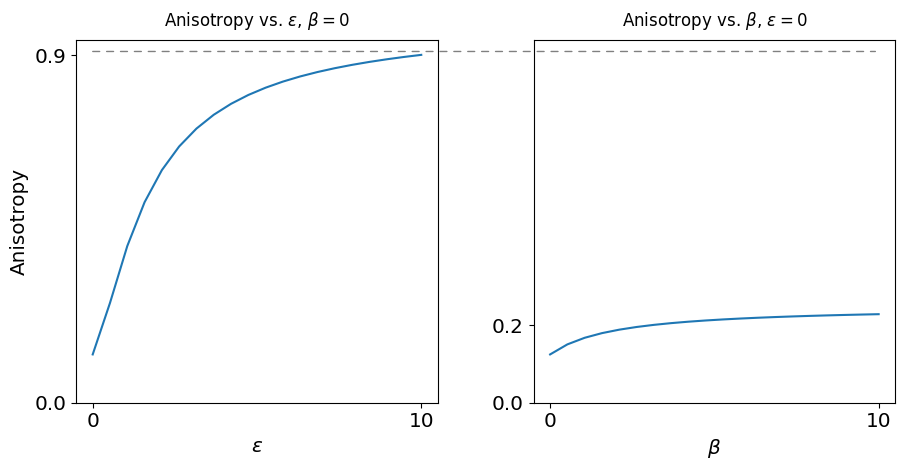

In [ ]:
plot_vs_isolated_params(metric_name="Anisotropy", metric_fnc=Anisotropy, eps_max=10, beta_max=10, log_scale=False, width_factor=1.5, line_offset=-0.03)

/tmp/ipykernel_2411/1455125048.py:33: RuntimeWarning: overflow encountered in exp
  ratio    = np.exp(log_r) # keep for diagnostics
/tmp/ipykernel_2411/1455125048.py:36: RuntimeWarning: overflow encountered in exp
  inner = np.exp(log_r) * kve_sum + np.exp(2 * arg) * ive_sum


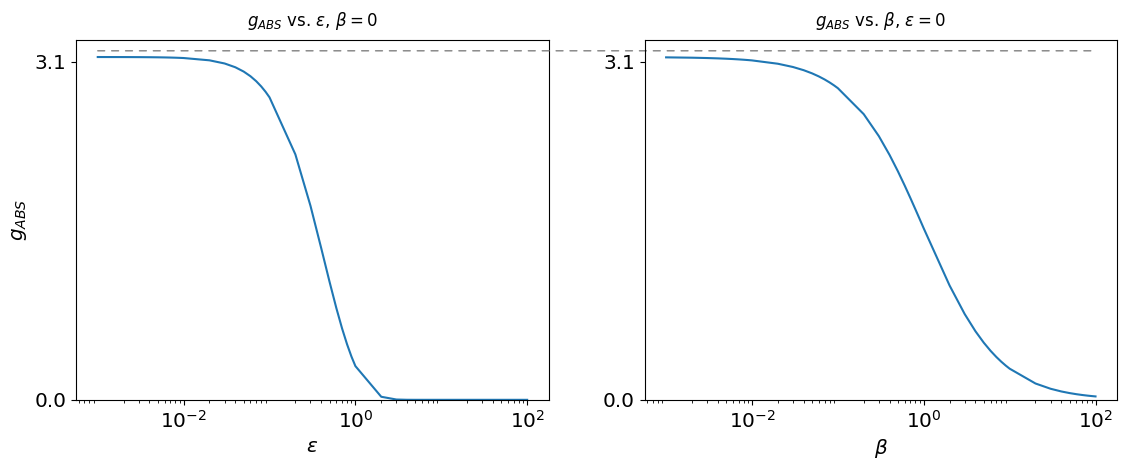

In [ ]:
plot_vs_isolated_params(metric_name="$g_{ABS}$", metric_fnc=g_abs, eps_max=100, beta_max=100, log_scale=True, width_factor=2, line_offset=-0.1)

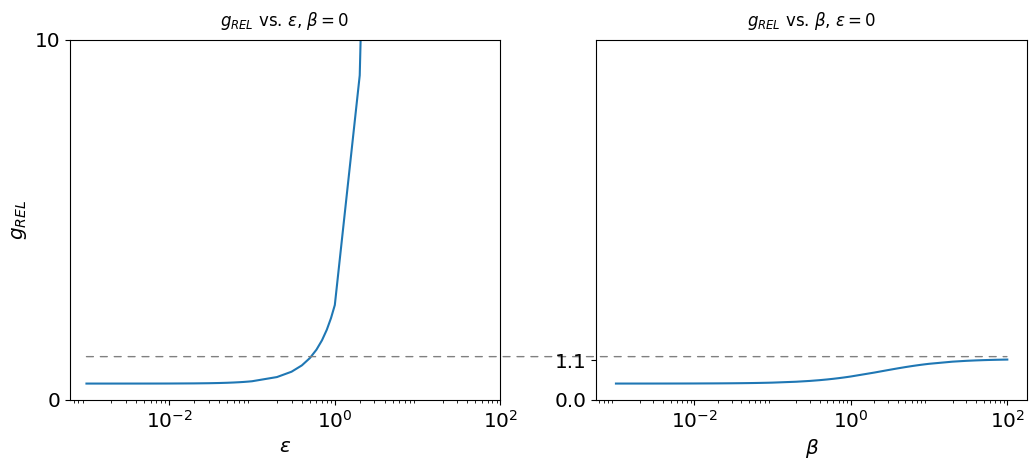

In [ ]:
plot_vs_isolated_params(metric_name="$g_{REL}$", metric_fnc=g_rel, eps_max=10, beta_max=100, log_scale=True, width_factor=2, height_limit=10, line_offset=-8.8)

/tmp/ipykernel_2411/1455125048.py:33: RuntimeWarning: overflow encountered in exp
  ratio    = np.exp(log_r) # keep for diagnostics
/tmp/ipykernel_2411/1455125048.py:36: RuntimeWarning: overflow encountered in exp
  inner = np.exp(log_r) * kve_sum + np.exp(2 * arg) * ive_sum
/tmp/ipykernel_2411/1455125048.py:36: RuntimeWarning: overflow encountered in scalar multiply
  inner = np.exp(log_r) * kve_sum + np.exp(2 * arg) * ive_sum
/tmp/ipykernel_2411/1549330886.py:7: RuntimeWarning: invalid value encountered in scalar divide
  return ( chi_f - chi_b ) / np.sqrt( chi_f + chi_b )


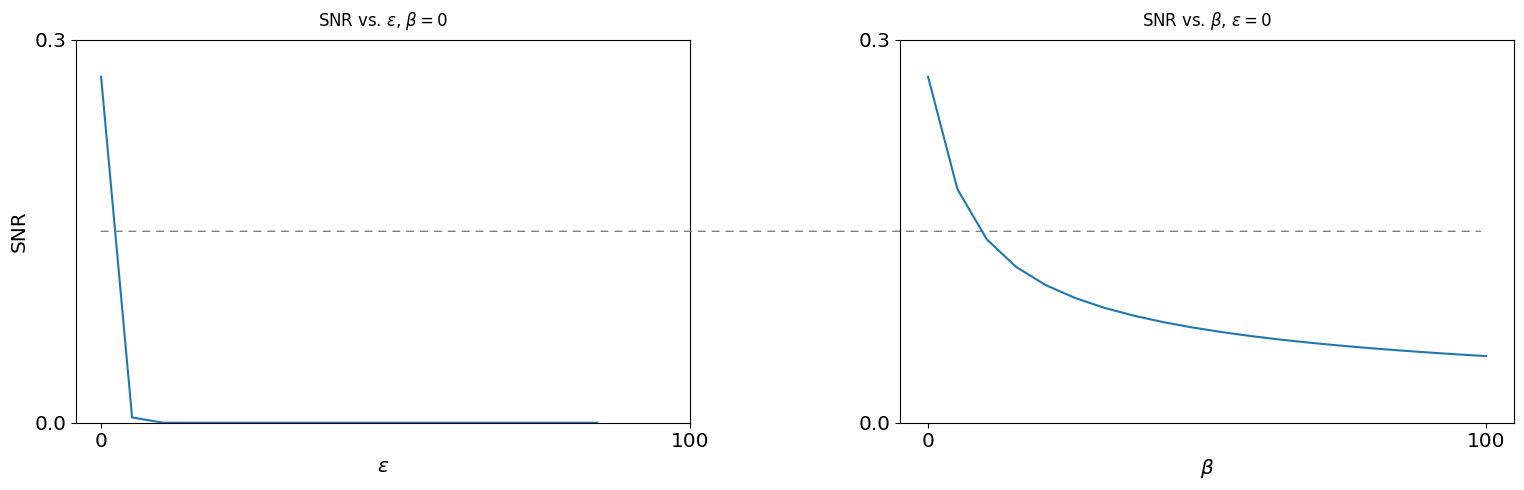

In [ ]:
fig, axes=plt.subplots(1, 2, figsize=(14, 5))
plot_vs_isolated_params(metric_name="SNR", metric_fnc=SNR, width_factor=1, axes=axes, use_avg=False)

In [ ]:
# def plot_for_multiple_kappas(kappa_vals, plot_fnc, figsize=(14, 5), **kwargs):
#   fig, axes = plt.subplots(1, len(kappa_vals), figsize)
#   for i in range(len(kappa_vals)):
#     set_kappa(kappa_vals[i])
#     print(kappa)
#     ax = axes if len(kappa_vals) == 1 else axes[i]
#     print(ax)
#     img = plot_fnc(ax=ax, **kwargs)
#     ax.set_title(f"$\\kappa={kappa}$")
#     if plot_fnc == plot_metric_heatmap: fig.colorbar(img, ax=ax, fraction=0.1)


In [ ]:
plot_for_multiple_kappas([0.02, 0.2, 5], plot_vs_isolated_params, (9, 15), True, 2, log_scale=True, eps_min=0.01, beta_min=0.01)

/tmp/ipykernel_2411/1455125048.py:33: RuntimeWarning: overflow encountered in exp
  ratio    = np.exp(log_r) # keep for diagnostics
/tmp/ipykernel_2411/1455125048.py:36: RuntimeWarning: overflow encountered in exp
  inner = np.exp(log_r) * kve_sum + np.exp(2 * arg) * ive_sum


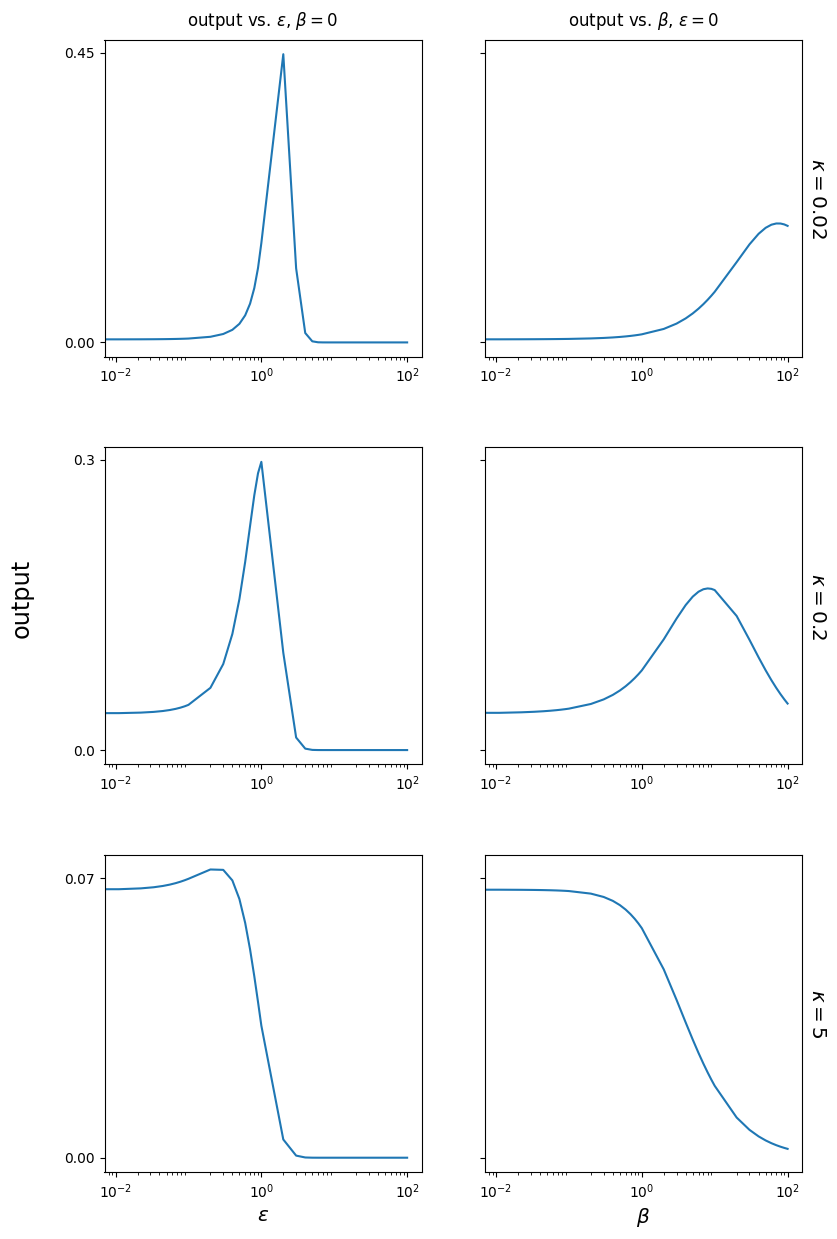

In [ ]:
from matplotlib.patches import ConnectionPatch

# plot_for_multiple_kappas([0.02, 0.2, 5], )
kappa_vals = [0.02, 0.2, 5]
fig, axes = plt.subplots(len(kappa_vals), 2, figsize=(9, 15), sharey='row')

for i in range(len(kappa_vals)):
  set_kappa(kappa_vals[i])

  set_alpha(1)
  set_beta(0)

  eps_max = 100
  div = 10
  eps_vals = np.concatenate((
      np.linspace(0, 0.1, div),
      np.linspace(0.1, 1, div),
      np.linspace(1, 10, div),
      np.linspace(10, 100, div)
  ))
  output_vals = np.array([])
  for eps_val in eps_vals:
    set_epsilon(eps_val)
    output_vals = np.append(output_vals, output())

  ax1_max = 1.0
  ax1 = axes[i][0]
  ax1.semilogx(eps_vals, output_vals)
  if i == len(kappa_vals)-1:
    ax1.set_xlabel("$\\epsilon$", fontsize="x-large")
  #   ax1.set_xticks([0.01, eps_max])
  # else:
  #   ax1.set_xticks([])
  ax1.set_xticks([0.01, 1, eps_max])
  # ax1.set_ylabel("output", fontsize="x-large")
  if np.round(max(output_vals), 1) == 0.0:
    ax1.set_yticks([0, np.round(max(output_vals), 2)])
  else:
    ax1.set_yticks([0, np.round(max(output_vals), 2)])
  # ax1.tick_params(labelsize="x-large")
  if i == 0:
    ax1.set_title(f"output vs. $\\varepsilon$, $\\beta=0$", pad=10)
  # else:
    # ax1.set_title(f"$\\kappa={kappa}$", pad=10)
  ax1.set_aspect(1.0/ax1.get_data_ratio(), adjustable='box')

  set_alpha(1)
  set_epsilon(0)

  beta_max = 100
  beta_vals = np.concatenate((
      np.linspace(0, 0.1, div),
      np.linspace(0.1, 1, div),
      np.linspace(1, 10, div),
      np.linspace(10, 100, div)
  ))
  output_vals = np.array([])
  for beta_val in beta_vals:
    set_beta(beta_val)
    output_vals = np.append(output_vals, output())

  ax2 = axes[i][1]
  ax2.semilogx(beta_vals, output_vals)
  if i == len(kappa_vals)-1:
    ax2.set_xlabel("$\\beta$", fontsize="x-large")
  #   ax2.set_xticks([0.01, beta_max])
  # else:
  #   ax2.set_xticks([])
  ax2.set_xticks([0.01, 1, beta_max])
  # ax2.set_yticks([0, np.round(max(output_vals), 1)])
  # ax2.tick_params(labelsize="x-large")
  if i == 0:
    ax2.set_title(f"output vs. $\\beta$, $\\varepsilon=0$", pad=10)
  # else:
    # ax2.set_title(f"$\\kappa={kappa}$", pad=10)
  # ax2.set_ylim(0.0, ax1_max)
  ax2.set_aspect(1.0/ax2.get_data_ratio(), adjustable='box')
  # ax2.set_yticks([0, np.round(max(output_vals), 1)])

  ax2.annotate(
    f"$\\kappa={kappa}$",
    xy=(1.02, 0.5),               # just outside the right edge, vertically centered
    xycoords="axes fraction",
    rotation=-90,                  # 90 degrees clockwise
    va="center",
    ha="left",
    fontsize="x-large",
    annotation_clip=False          # allows drawing outside the axes bounds
  )

# plt.tight_layout()
fig.supylabel("output", size="xx-large")

plt.show()

Below are drafts/deprecated

Text(0.5, 1.0, 'Anisotropy vs. epsilon (degrading parameter)')

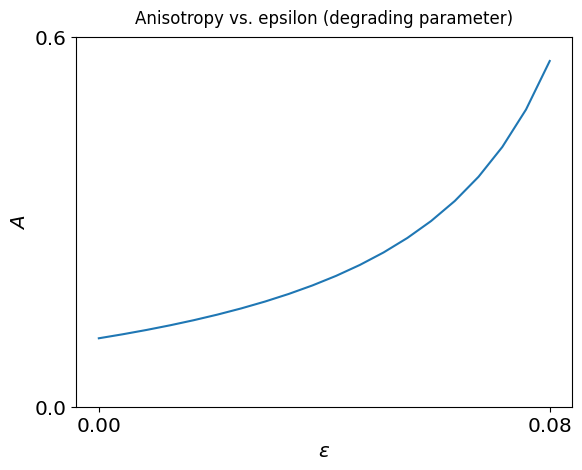

In [ ]:
# set_rho_0(3)
# set_alpha(0.5)

# eps_max = 0.08
# eps_vals = np.linspace(0, eps_max, 20)
# anisotropy_vals = np.array([])
# for eps_val in eps_vals:
#   set_epsilon(eps_val)
#   anisotropy_vals = np.append(anisotropy_vals, Anisotropy_Lefebre())

# plt.plot(eps_vals, anisotropy_vals)
# ax = plt.gca()
# ax.set_xlabel("$\\epsilon$", fontsize="x-large")
# ax.set_ylabel("$A$", fontsize="x-large")
# ax.set_xticks([0, eps_max])
# ax.set_yticks([0, np.round(max(anisotropy_vals), 1)])
# ax.tick_params(labelsize="x-large")
# ax.set_title("Anisotropy vs. epsilon (degrading parameter)", pad=10)

# # So the behavior can match theirs with alpha at a certain amount (~0.8).
# # But the more I look at this, the more this behavior seems unreasonable.
# # You're telling me if the cell could keep arbitrarily increasing epsilon,
# # the Anisotropy would keep increasing at an exponential rate? After a while
# # you're going to run out of pheromone to kill and each enzyme will bring
# # less and less reward as there's less chance it will even come into contact
# # with a pheromone molecule.
# # That's the behavior my graph exhibits, which is why I feel like it makes
# # more sense. To be fair, this could have to do with the fact that there
# # is an extra parameter in our case vs. theirs.
# # I guess technically, yeah, if the cell boundary was nonexistent to the
# # pheromone (Lefebre), the enzyme would just keep degrading it at all points
# # in space until you get to like 2 molecules in the front of the cell and 0
# # molecules in the back == woahhh infinite anisotropy!!
# # Whereas in our case, the anisotropy is limited by the boundary condition
# # and thus by beta. Does that make sense? Maybe.
# # Here's why I think maybe: it forces some of the pheromone to bounce off,
# # which maybe does something?? Also it avoids the limiting case where there's
# # like two molecules in the front to zero on the back because any molecule in
# # that small of a concentration will get removed at the cell boundary.
# # Maybe. Still talk to Dr. Mugler about this.
# # LEAVE-OFF POINT 5/15/26

In [ ]:
def SNR_small_approx ():
  return 3 * np.sqrt(alpha) / ( 2 * rho_0 ** (3/2) ) #* 1 / np.sqrt(1 + (epsilon ** 2) / 2)

def SNR_large_approx ():
  return 3 * np.exp( epsilon * (1 - np.sqrt(rho_0)) ) / rho_0 ** (3/8) * np.sqrt( 2*alpha / (1 + 2*epsilon) )

Max SNR = 0.44038399993764415, occurring at epsilon = 0.5875
Max SNR Small Approximation = 0.37947331922020555, occurring at epsilon = 0.01
Max SNR Large Approximation = 2.9619983315080485, occurring at epsilon = 0.01


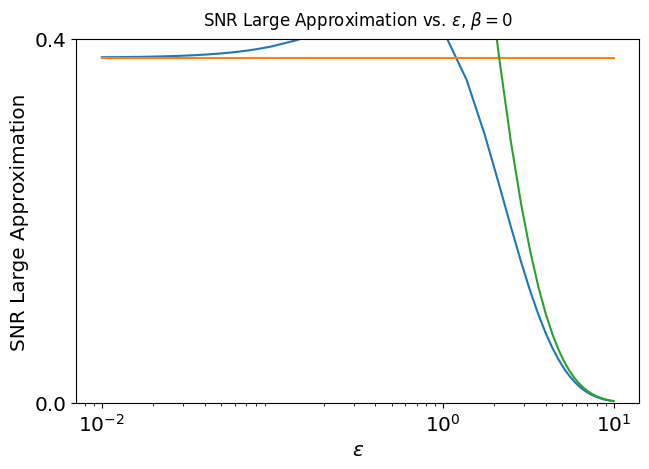

Max SNR = 0.2206198331542802, occurring at epsilon = 0.475
Max SNR Small Approximation = 0.1875, occurring at epsilon = 0.01
Max SNR Large Approximation = 2.4729806892610813, occurring at epsilon = 0.01


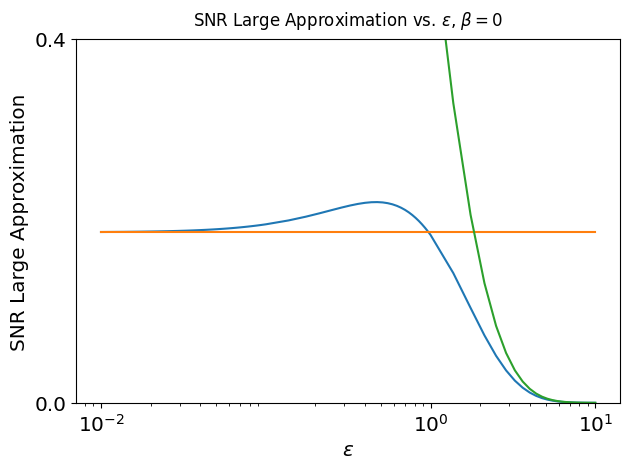

Max SNR = 0.1212801995613748, occurring at epsilon = 0.4
Max SNR Small Approximation = 0.10206207261596575, occurring at epsilon = 0.01
Max SNR Large Approximation = 2.114630022448252, occurring at epsilon = 0.01


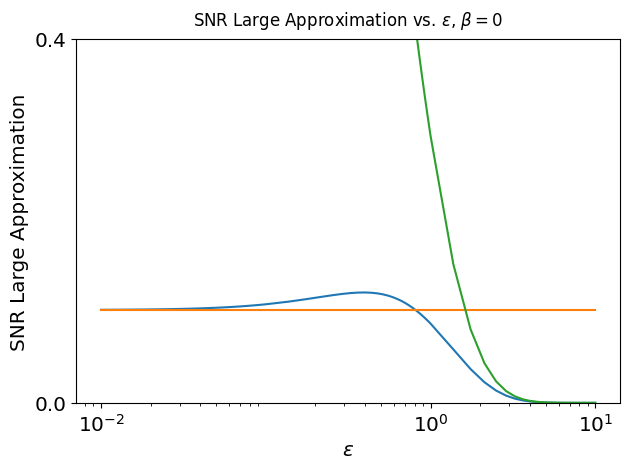

In [ ]:
rho_0_vals = [2.5, 4, 6]
for val in rho_0_vals:
  set_rho_0(val)
  plot_vs_isolated_params(metric_name="SNR", metric_fnc=new_SNR, eps_min=0.01, eps_max=10, log_scale=True, enabled_params=(True, False), width_factor=1)
  plot_vs_isolated_params(metric_name="SNR Small Approximation", metric_fnc=SNR_small_approx, eps_min=0.01, eps_max=10, log_scale=True, enabled_params=(True, False), width_factor=1)
  plot_vs_isolated_params(metric_name="SNR Large Approximation", metric_fnc=SNR_large_approx, eps_min=0.01, eps_max=10, log_scale=True, enabled_params=(True, False), width_factor=1)
  ax = plt.gca()
  ax.set_yticks([0.0, 0.4])
  ax.set_ylim(0.0, 0.4)
  plt.show()

In [ ]:
100 // 0.1

999.0

In [ ]:
rho_0_min = 2.1
rho_0_max = 21000

rho_0_vals = np.array([])
val = rho_0_min
while val < rho_0_max:
  arr = np.linspace(val, val * 10, 50)
  rho_0_vals = np.append(rho_0_vals, arr)
  val *= 10
max_eps_vals = []
for val in rho_0_vals:
  set_rho_0(val)
  print(f"rho_0 = {rho_0}")
  max_eps_val = plot_vs_isolated_params(metric_name="SNR", metric_fnc=new_SNR, eps_min=0.001, eps_max=10, log_scale=True, enabled_params=(True, False), width_factor=1)
  max_eps_vals.append(max_eps_val)

fig = plt.gcf()
ax = plt.gca()
fig.set_size_inches(0.5, 0.5)
plt.show()
offset = -0.05
plt.ion()
plt.loglog(rho_0_vals, 1 / np.sqrt(rho_0_vals) + offset, color="red", label="$\\varepsilon^*\\sim \\rho_0^{-1/\\,2}$")
plt.scatter(rho_0_vals, max_eps_vals, color="blue", label="$\\varepsilon^*$ of SNR vs. $\\rho_0$")
# slope = ( np.log(max_eps_vals[-1]) - np.log(max_eps_vals[0]) ) / ( np.log(rho_0_vals[-1]) - np.log(rho_0_vals[0]) )
# alt_slope = np.log(max_eps_vals[-1] / max_eps_vals[0]) / np.log(rho_0_vals[-1] / rho_0_vals[0])
# print(slope)
# print(alt_slope)
# offset = -0.03
# plt.loglog(rho_0_vals, 1 / np.sqrt(rho_0_vals) + offset, color="green", label=f"$\\varepsilon^*\\sim \\rho_0^{{{slope}}}$")

from scipy.optimize import curve_fit

def linear(log_x, m, c):
    return m * log_x + c

popt, _ = curve_fit(linear, np.log(rho_0_vals), np.log(max_eps_vals))
plt.loglog(rho_0_vals, np.exp(linear(np.log(rho_0_vals), *popt)), color="purple", label=f"$\\varepsilon^*\\sim \\rho_0^{{{popt[0]:.6f}}}$")
# plt.loglog(rho_0_vals, np.log(rho_0_vals), color="yellow", label=f"$\\ln(\\rho_0)$")

plt.xlabel("$\\rho_0$", fontsize="x-large")
plt.ylabel("$\\varepsilon^*$", fontsize="x-large")
plt.legend()


rho_0 = 2.1
Max SNR = 0.5688971831075128, occurring at epsilon = 0.6158316633266533
rho_0 = 2.4857142857142858
Max SNR = 0.44416683703369453, occurring at epsilon = 0.5716432865731463
rho_0 = 2.8714285714285714
Max SNR = 0.35934518346951594, occurring at epsilon = 0.537374749498998
rho_0 = 3.257142857142857
Max SNR = 0.29855404218439785, occurring at epsilon = 0.5094188376753507
rho_0 = 3.642857142857143
Max SNR = 0.2532164827921443, occurring at epsilon = 0.48507014028056117
rho_0 = 4.0285714285714285
Max SNR = 0.21833118888288056, occurring at epsilon = 0.4652304609218437
rho_0 = 4.414285714285715
Max SNR = 0.1908038710665085, occurring at epsilon = 0.44719438877755513
rho_0 = 4.8
Max SNR = 0.16862738080890216, occurring at epsilon = 0.43186372745490986
rho_0 = 5.185714285714285
Max SNR = 0.1504483420155596, occurring at epsilon = 0.41743486973947896
rho_0 = 5.571428571428571
Max SNR = 0.1353242812643899, occurring at epsilon = 0.4048096192384769
rho_0 = 5.957142857142857
Max SNR = 0

In [ ]:
ax.loglog(rho_0_vals, 1 / np.sqrt(rho_0_vals) + offset, color="red", label="$\\varepsilon^*\\sim \\rho_0^{-1/\\,2}$")
fig.canvas.draw()

In [ ]:
import scipy.constants as const

def find_constant(value, n=10, by="ratio"):
    results = []
    for name, (val, unit, unc) in const.physical_constants.items():
        if val == 0:
            continue
        abs_err = abs(value - val)
        rel_err = abs_err / abs(val)
        results.append((name, val, unit, abs_err, rel_err))
    key = (lambda r: r[4]) if by == "ratio" else (lambda r: r[3])
    results.sort(key=key)
    for name, val, unit, abs_err, rel_err in results[:n]:
        print(f"{rel_err:.3e}  {val:.6e} {unit:>12}  {name}")
    return results[:n]

find_constant(0.426877)

1.646e-01  5.109989e-01        MeV/c  natural unit of momentum in MeV/c
1.646e-01  5.109989e-01        MeV/c  natural unit of mom.um in MeV/c
1.646e-01  5.109990e-01          MeV  electron mass energy equivalent in MeV
1.646e-01  5.109990e-01          MeV  natural unit of energy in MeV
1.916e-01  5.280510e-01               proton-tau mass ratio
1.927e-01  5.287790e-01               neutron-tau mass ratio
3.645e-01  6.717138e-01       K T^-1  Bohr magneton in K/T
3.904e-01  3.070122e-01               deuteron-proton mag. mom. ratio
3.904e-01  3.070122e-01               deuteron-proton magn. moment ratio
5.021e-01  8.574382e-01               deuteron magn. moment to nuclear magneton ratio


[('natural unit of momentum in MeV/c',
  0.5109989461,
  'MeV/c',
  0.08412194609999996,
  0.16462254324011405),
 ('natural unit of mom.um in MeV/c',
  0.5109989461,
  'MeV/c',
  0.08412194609999996,
  0.16462254324011405),
 ('electron mass energy equivalent in MeV',
  0.51099895069,
  'MeV',
  0.08412195069,
  0.16462255074381354),
 ('natural unit of energy in MeV',
  0.51099895069,
  'MeV',
  0.08412195069,
  0.16462255074381354),
 ('proton-tau mass ratio',
  0.528051,
  '',
  0.10117400000000004,
  0.19159891752879937),
 ('neutron-tau mass ratio',
  0.528779,
  '',
  0.10190199999999999,
  0.1927118890878798),
 ('Bohr magneton in K/T',
  0.67171381472,
  'K T^-1',
  0.24483681472000002,
  0.3644957262373096),
 ('deuteron-proton mag. mom. ratio',
  0.3070122093,
  '',
  0.1198647907,
  0.39042353062536655),
 ('deuteron-proton magn. moment ratio',
  0.3070122084,
  '',
  0.11986479160000002,
  0.39042353470136476),
 ('deuteron magn. moment to nuclear magneton ratio',
  0.8574382329,
 